In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

## 📊 데이터 전처리 (Data Preprocessing)

In [3]:
df = pd.read_csv('/Users/othree/Cognitive Reserve Modeling/Data/ADNI1234_clinic-sent-Ariel-04-17-2025.csv')

print("="*50)
print("데이터 로드 완료!")
print("="*50)
print(f"전체 행 수: {df.shape[0]:,}")
print(f"전체 열 수: {df.shape[1]:,}")
print(f"총 데이터 포인트: {df.shape[0] * df.shape[1]:,}")

데이터 로드 완료!
전체 행 수: 4,508
전체 열 수: 127
총 데이터 포인트: 572,516


In [4]:
print("="*50)
print("데이터 타입 및 결측치 정보")
print("="*50)
df.info()

데이터 타입 및 결측치 정보
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4508 entries, 0 to 4507
Columns: 127 entries, New_Path to update_stamp
dtypes: float64(87), int64(9), object(31)
memory usage: 4.4+ MB


In [5]:
print("="*50)
print(f"전체 컬럼 목록 (총 {len(df.columns)}개)")
print("="*50)
for i, col in enumerate(df.columns, 1):
    print(f"{i:3d}. {col}")

전체 컬럼 목록 (총 127개)
  1. New_Path
  2. Image Data ID
  3. Subject
  4. Group-RS:InitialDX
  5. Sex
  6. Age
  7. Visit
  8. Description
  9. Acq Date
 10. RS:DX_fill
 11. DX2
 12. RID
 13. COLPROT
 14. ORIGPROT
 15. PTID
 16. SITE
 17. VISCODE
 18. EXAMDATE
 19. DX_bl
 20. AGE
 21. PTGENDER
 22. PTEDUCAT
 23. PTETHCAT
 24. PTRACCAT
 25. PTMARRY
 26. APOE4
 27. FDG
 28. PIB
 29. AV45
 30. FBB
 31. ABETA
 32. TAU
 33. PTAU
 34. CDRSB
 35. ADAS11
 36. ADAS13
 37. ADASQ4
 38. MMSE
 39. RAVLT_immediate
 40. RAVLT_learning
 41. RAVLT_forgetting
 42. RAVLT_perc_forgetting
 43. LDELTOTAL
 44. DIGITSCOR
 45. TRABSCOR
 46. FAQ
 47. MOCA
 48. EcogPtMem
 49. EcogPtLang
 50. EcogPtVisspat
 51. EcogPtPlan
 52. EcogPtOrgan
 53. EcogPtDivatt
 54. EcogPtTotal
 55. EcogSPMem
 56. EcogSPLang
 57. EcogSPVisspat
 58. EcogSPPlan
 59. EcogSPOrgan
 60. EcogSPDivatt
 61. EcogSPTotal
 62. FLDSTRENG
 63. FSVERSION
 64. IMAGEUID
 65. Ventricles
 66. Hippocampus
 67. WholeBrain
 68. Entorhinal
 69. Fusiform
 70. Mid

In [6]:
# 결측치 분석
print("="*50)
print("결측치 분석")
print("="*50)

missing_data = pd.DataFrame({
    '결측치 개수': df.isnull().sum(),
    '결측치 비율(%)': (df.isnull().sum() / len(df) * 100).round(2)
})

# 결측치가 있는 컬럼만 필터링
missing_data = missing_data[missing_data['결측치 개수'] > 0].sort_values('결측치 개수', ascending=False)

if len(missing_data) > 0:
    print(f"\n결측치가 있는 컬럼: {len(missing_data)}개\n")
    print(missing_data)
else:
    print("\n✅ 결측치가 없습니다!")

결측치 분석

결측치가 있는 컬럼: 86개

              결측치 개수  결측치 비율(%)
FBB_bl          4508     100.00
FBB             4508     100.00
PIB_bl          4431      98.29
PIB             4349      96.47
AV45            3745      83.07
...              ...        ...
mPACCdigit        12       0.27
mPACCtrailsB      12       0.27
MMSE               7       0.16
ADAS11_bl          4       0.09
APOE4              3       0.07

[86 rows x 2 columns]


In [7]:
print("="*50)
print("중복 데이터 확인")
print("="*50)

duplicates = df.duplicated().sum()
print(f"중복된 행 수: {duplicates:,}개")
print(f"중복 비율: {(duplicates / len(df) * 100):.2f}%")

if duplicates > 0:
    print("\n⚠️ 중복 데이터가 발견되었습니다.")
else:
    print("\n중복 데이터가 없습니다!")

중복 데이터 확인
중복된 행 수: 0개
중복 비율: 0.00%

중복 데이터가 없습니다!


In [8]:
print("="*50)
print("데이터 타입별 컬럼 분류")
print("="*50)

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
datetime_cols = df.select_dtypes(include=['datetime64']).columns.tolist()

print(f"\n숫자형 컬럼: {len(numeric_cols)}개")
print(f"범주형 컬럼: {len(categorical_cols)}개")
print(f"날짜형 컬럼: {len(datetime_cols)}개")

print(f"\n숫자형 컬럼 목록:")
for col in numeric_cols[:10]:  # 처음 10개만 출력
    print(f"  - {col}")
if len(numeric_cols) > 10:
    print(f"  ... 외 {len(numeric_cols) - 10}개")

print(f"\n범주형 컬럼 목록:")
for col in categorical_cols[:10]:  # 처음 10개만 출력
    print(f"  - {col}")
if len(categorical_cols) > 10:
    print(f"  ... 외 {len(categorical_cols) - 10}개")

데이터 타입별 컬럼 분류

숫자형 컬럼: 96개
범주형 컬럼: 31개
날짜형 컬럼: 0개

숫자형 컬럼 목록:
  - Image Data ID
  - Age
  - DX2
  - RID
  - SITE
  - AGE
  - PTEDUCAT
  - APOE4
  - FDG
  - PIB
  ... 외 86개

범주형 컬럼 목록:
  - New_Path
  - Subject
  - Group-RS:InitialDX
  - Sex
  - Visit
  - Description
  - Acq Date
  - RS:DX_fill
  - COLPROT
  - ORIGPROT
  ... 외 21개


In [9]:
print("="*50)
print("결측치 기준으로 데이터 분리")
print("="*50)

# 각 컬럼의 결측치 비율 계산
missing_ratio = (df.isnull().sum() / len(df) * 100)

# 결측치가 50% 이상인 컬럼
high_missing_cols = missing_ratio[missing_ratio >= 50].index.tolist()

# 결측치가 50% 미만인 컬럼
low_missing_cols = missing_ratio[missing_ratio < 50].index.tolist()

# MOCA를 결측치 50% 미만 그룹에 강제 포함
if 'MOCA' in high_missing_cols:
    high_missing_cols.remove('MOCA')
    low_missing_cols.append('MOCA')
    print(f"⚠️  MOCA 컬럼을 결측치 50% 미만 그룹으로 이동 (원래 결측치: {missing_ratio['MOCA']:.2f}%)")
elif 'MOCA' in low_missing_cols:
    print(f"✅ MOCA 컬럼은 이미 결측치 50% 미만 그룹에 포함되어 있습니다 (결측치: {missing_ratio['MOCA']:.2f}%)")

print(f"\n✅ 결측치 50% 이상 컬럼: {len(high_missing_cols)}개")
print(f"✅ 결측치 50% 미만 컬럼: {len(low_missing_cols)}개")

# 두 개의 데이터프레임으로 분리
df_high_missing = df[high_missing_cols]
df_low_missing = df[low_missing_cols]

# CSV 파일로 저장
output_path_high = '/Users/othree/Cognitive Reserve Modeling/Data/ADNI_high_missing_50percent.csv'
output_path_low = '/Users/othree/Cognitive Reserve Modeling/Data/ADNI_low_missing_50percent.csv'

df_high_missing.to_csv(output_path_high, index=False)
df_low_missing.to_csv(output_path_low, index=False)

print(f"\n📁 파일 저장 완료!")
print(f"   - 결측치 50% 이상: {output_path_high}")
print(f"     (행: {df_high_missing.shape[0]:,}, 열: {df_high_missing.shape[1]})")
print(f"   - 결측치 50% 미만: {output_path_low}")
print(f"     (행: {df_low_missing.shape[0]:,}, 열: {df_low_missing.shape[1]})")

# 결측치 50% 이상 컬럼 목록 출력
print(f"\n📊 결측치 50% 이상 컬럼 목록:")
for i, col in enumerate(high_missing_cols, 1):
    ratio = missing_ratio[col]
    print(f"   {i:2d}. {col:30s} - 결측치: {ratio:.2f}%")

# 결측치 통계
print(f"\n📈 결측치 통계:")
print(f"   - 결측치 50% 이상 평균: {missing_ratio[high_missing_cols].mean():.2f}%")
print(f"   - 결측치 50% 미만 평균: {missing_ratio[low_missing_cols].mean():.2f}%")

결측치 기준으로 데이터 분리


⚠️  MOCA 컬럼을 결측치 50% 미만 그룹으로 이동 (원래 결측치: 64.69%)

✅ 결측치 50% 이상 컬럼: 39개
✅ 결측치 50% 미만 컬럼: 88개

📁 파일 저장 완료!
   - 결측치 50% 이상: /Users/othree/Cognitive Reserve Modeling/Data/ADNI_high_missing_50percent.csv
     (행: 4,508, 열: 39)
   - 결측치 50% 미만: /Users/othree/Cognitive Reserve Modeling/Data/ADNI_low_missing_50percent.csv
     (행: 4,508, 열: 88)

📊 결측치 50% 이상 컬럼 목록:
    1. FDG                            - 결측치: 56.83%
    2. PIB                            - 결측치: 96.47%
    3. AV45                           - 결측치: 83.07%
    4. FBB                            - 결측치: 100.00%
    5. ABETA                          - 결측치: 72.20%
    6. TAU                            - 결측치: 72.20%
    7. PTAU                           - 결측치: 72.20%
    8. EcogPtMem                      - 결측치: 64.73%
    9. EcogPtLang                     - 결측치: 64.88%
   10. EcogPtVisspat                  - 결측치: 65.24%
   11. EcogPtPlan                     - 결측치: 64.97%
   12. EcogPtOrgan                    - 결측치: 65.79%
   13. EcogPtD

데이터 Timeline 분석

📅 영상 촬영 날짜 (Acq Date) 분석:
   - 형식: object
   - 샘플: ['2/16/07', '10/11/07', '5/29/08']
   - 최초 날짜: 2005-08-26 00:00:00
   - 최종 날짜: 2017-01-30 00:00:00
   - 총 기간: 4175일 (11.4년)
   - 유효한 날짜: 4,508개

📅 검사 날짜 (EXAMDATE) 분석:
   - 형식: object
   - 샘플: ['2007-02-23', '2007-10-04', '2008-03-03']
   - 최초 날짜: 2005-09-07 00:00:00
   - 최종 날짜: 2017-01-30 00:00:00
   - 총 기간: 4163일 (11.4년)
   - 유효한 날짜: 4,508개

📊 Baseline으로부터의 시간 분석:
   - Years_bl 범위: 0.00년 ~ 10.75년
   - 최대 추적 기간: 10.75년 (129.0개월)
   - Month_bl 범위: 0.0개월 ~ 128.8개월

📈 연도별 데이터 수집 건수:
   - 2005년: 45건
   - 2006년: 803건
   - 2007년: 1,118건
   - 2008년: 695건
   - 2009년: 131건
   - 2010년: 82건
   - 2011년: 253건
   - 2012년: 610건
   - 2013년: 446건
   - 2014년: 157건
   - 2015년: 91건
   - 2016년: 74건
   - 2017년: 3건


/var/folders/zb/yqyg0k1554l0vj7zf6mzbm240000gn/T/ipykernel_62296/1054684297.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Acq Date_parsed'] = pd.to_datetime(df['Acq Date'], errors='coerce')
/var/folders/zb/yqyg0k1554l0vj7zf6mzbm240000gn/T/ipykernel_62296/1054684297.py:70: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zb/yqyg0k1554l0vj7zf6mzbm240000gn/T/ipykernel_62296/1054684297.py:70: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zb/yqyg0k1554l0vj7zf6mzbm240000gn/T/ipykernel_62296/1054684297.py:70: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zb/yqyg0k1554l0vj7zf6mzbm240000gn/T/ipykernel_62296/1054684297.py:70: UserWarn

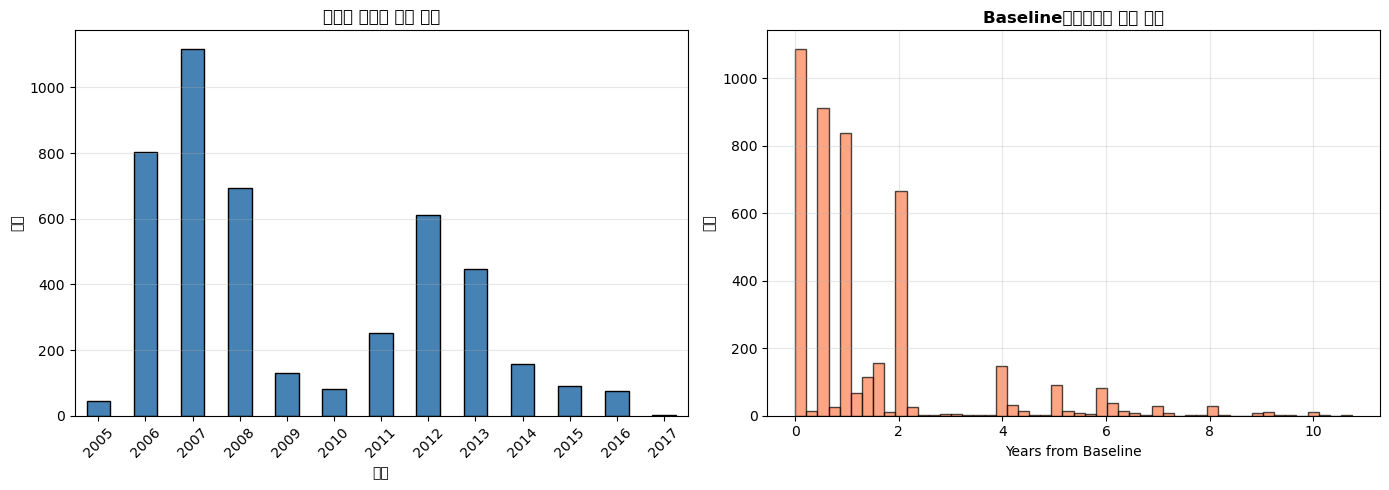


📋 Visit별 데이터 분포:
   - sc: 731건
   - m06: 658건
   - m12: 623건
   - m24: 510건
   - v11: 397건
   - v02: 356건
   - v05: 291건
   - m18: 269건
   - v21: 244건
   - v06: 170건

👥 피험자별 추적 기간 분석:
   - 총 피험자 수: 1,122명
   - 평균 추적 기간: 2.58년
   - 최대 추적 기간: 10.11년
   - 최소 추적 기간: 0.00년
   - 피험자당 평균 방문 횟수: 4.0회


In [10]:
print("="*50)
print("데이터 Timeline 분석")
print("="*50)

# 날짜 컬럼들 확인
date_columns = ['Acq Date', 'EXAMDATE', 'EXAMDATE_bl', 'update_stamp']

# Acq Date 분석 (영상 촬영 날짜)
print("\n📅 영상 촬영 날짜 (Acq Date) 분석:")
print(f"   - 형식: {df['Acq Date'].dtype}")
print(f"   - 샘플: {df['Acq Date'].head(3).tolist()}")

# 날짜를 datetime으로 변환
df['Acq Date_parsed'] = pd.to_datetime(df['Acq Date'], errors='coerce')

if df['Acq Date_parsed'].notna().sum() > 0:
    print(f"   - 최초 날짜: {df['Acq Date_parsed'].min()}")
    print(f"   - 최종 날짜: {df['Acq Date_parsed'].max()}")
    date_range = df['Acq Date_parsed'].max() - df['Acq Date_parsed'].min()
    print(f"   - 총 기간: {date_range.days}일 ({date_range.days/365.25:.1f}년)")
    print(f"   - 유효한 날짜: {df['Acq Date_parsed'].notna().sum():,}개")

# EXAMDATE 분석
print("\n📅 검사 날짜 (EXAMDATE) 분석:")
print(f"   - 형식: {df['EXAMDATE'].dtype}")
print(f"   - 샘플: {df['EXAMDATE'].head(3).tolist()}")

df['EXAMDATE_parsed'] = pd.to_datetime(df['EXAMDATE'], errors='coerce')

if df['EXAMDATE_parsed'].notna().sum() > 0:
    print(f"   - 최초 날짜: {df['EXAMDATE_parsed'].min()}")
    print(f"   - 최종 날짜: {df['EXAMDATE_parsed'].max()}")
    date_range = df['EXAMDATE_parsed'].max() - df['EXAMDATE_parsed'].min()
    print(f"   - 총 기간: {date_range.days}일 ({date_range.days/365.25:.1f}년)")
    print(f"   - 유효한 날짜: {df['EXAMDATE_parsed'].notna().sum():,}개")

# Years_bl, Month_bl 분석 (baseline으로부터의 시간)
print("\n📊 Baseline으로부터의 시간 분석:")
print(f"   - Years_bl 범위: {df['Years_bl'].min():.2f}년 ~ {df['Years_bl'].max():.2f}년")
print(f"   - 최대 추적 기간: {df['Years_bl'].max():.2f}년 ({df['Years_bl'].max()*12:.1f}개월)")
print(f"   - Month_bl 범위: {df['Month_bl'].min():.1f}개월 ~ {df['Month_bl'].max():.1f}개월")

# 연도별 데이터 분포
if df['Acq Date_parsed'].notna().sum() > 0:
    print("\n📈 연도별 데이터 수집 건수:")
    df['Year'] = df['Acq Date_parsed'].dt.year
    year_counts = df['Year'].value_counts().sort_index()
    for year, count in year_counts.items():
        if pd.notna(year):
            print(f"   - {int(year)}년: {count:,}건")
    
    # 연도별 시각화
    plt.figure(figsize=(14, 5))
    
    plt.subplot(1, 2, 1)
    year_counts.plot(kind='bar', color='steelblue', edgecolor='black')
    plt.title('연도별 데이터 수집 건수', fontsize=12, fontweight='bold')
    plt.xlabel('연도')
    plt.ylabel('건수')
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.hist(df['Years_bl'].dropna(), bins=50, color='coral', edgecolor='black', alpha=0.7)
    plt.title('Baseline으로부터의 시간 분포', fontsize=12, fontweight='bold')
    plt.xlabel('Years from Baseline')
    plt.ylabel('빈도')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Visit별 데이터 분포
print("\n📋 Visit별 데이터 분포:")
visit_counts = df['Visit'].value_counts()
for visit, count in visit_counts.head(10).items():
    print(f"   - {visit}: {count:,}건")

# Subject별 추적 기간
print("\n👥 피험자별 추적 기간 분석:")
subject_timeline = df.groupby('Subject').agg({
    'Years_bl': ['min', 'max', 'count'],
    'Acq Date_parsed': ['min', 'max']
})
subject_timeline['follow_up_years'] = subject_timeline[('Years_bl', 'max')] - subject_timeline[('Years_bl', 'min')]

print(f"   - 총 피험자 수: {df['Subject'].nunique():,}명")
print(f"   - 평균 추적 기간: {subject_timeline['follow_up_years'].mean():.2f}년")
print(f"   - 최대 추적 기간: {subject_timeline['follow_up_years'].max():.2f}년")
print(f"   - 최소 추적 기간: {subject_timeline['follow_up_years'].min():.2f}년")
print(f"   - 피험자당 평균 방문 횟수: {subject_timeline[('Years_bl', 'count')].mean():.1f}회")

In [11]:
print("="*50)
print("결측치 패턴 분석")
print("="*50)

# 1. 결측치 비율별 컬럼 분류
missing_ratio = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

print("\n📊 결측치 비율별 컬럼 분류:")
print(f"   - 결측치 90% 이상: {(missing_ratio >= 90).sum()}개")
print(f"   - 결측치 70-90%: {((missing_ratio >= 70) & (missing_ratio < 90)).sum()}개")
print(f"   - 결측치 50-70%: {((missing_ratio >= 50) & (missing_ratio < 70)).sum()}개")
print(f"   - 결측치 30-50%: {((missing_ratio >= 30) & (missing_ratio < 50)).sum()}개")
print(f"   - 결측치 10-30%: {((missing_ratio >= 10) & (missing_ratio < 30)).sum()}개")
print(f"   - 결측치 10% 미만: {((missing_ratio > 0) & (missing_ratio < 10)).sum()}개")
print(f"   - 결측치 없음: {(missing_ratio == 0).sum()}개")

# 2. 주요 임상 변수들의 결측치 현황
clinical_vars = ['MMSE', 'ADAS11', 'ADAS13', 'CDRSB', 'FAQ', 'MOCA', 
                 'RAVLT_immediate', 'LDELTOTAL', 'DIGITSCOR', 'TRABSCOR']
existing_clinical = [var for var in clinical_vars if var in df.columns]

print("\n📋 주요 임상 변수 결측치 현황:")
for var in existing_clinical:
    missing_pct = (df[var].isnull().sum() / len(df) * 100)
    print(f"   - {var:20s}: {missing_pct:5.2f}% ({df[var].isnull().sum():,}개)")

# 3. Baseline vs Follow-up 결측치 비교
baseline_cols = [col for col in df.columns if col.endswith('_bl')]
print(f"\n🔍 Baseline 변수: {len(baseline_cols)}개")

# baseline과 follow-up 비교
comparison_vars = ['MMSE', 'ADAS11', 'CDRSB', 'FAQ']
print("\n📊 Baseline vs Current 결측치 비교:")
for var in comparison_vars:
    if var in df.columns and f"{var}_bl" in df.columns:
        curr_missing = (df[var].isnull().sum() / len(df) * 100)
        bl_missing = (df[f"{var}_bl"].isnull().sum() / len(df) * 100)
        print(f"   - {var:10s}: Current {curr_missing:5.2f}% | Baseline {bl_missing:5.2f}%")

# 4. 진단 그룹별 결측치 패턴
print("\n🏥 진단 그룹별 주요 변수 결측치:")
for var in ['MMSE', 'ADAS11', 'MOCA']:
    if var in df.columns:
        print(f"\n   [{var}]")
        for dx in ['CN', 'MCI', 'AD']:
            if dx in df['Group-RS:InitialDX'].values:
                mask = df['Group-RS:InitialDX'] == dx
                missing_pct = (df.loc[mask, var].isnull().sum() / mask.sum() * 100)
                print(f"      - {dx}: {missing_pct:5.2f}%")

# 5. 시간대별 결측치 패턴 (Visit별)
print("\n📅 Visit별 MMSE 결측치 패턴:")
if 'MMSE' in df.columns:
    visit_missing = df.groupby('Visit')['MMSE'].apply(lambda x: (x.isnull().sum() / len(x) * 100))
    for visit, missing_pct in visit_missing.sort_index().head(10).items():
        count = df[df['Visit'] == visit].shape[0]
        print(f"   - {visit:5s}: {missing_pct:5.2f}% (n={count:,})")

# 6. 같은 피험자 내에서 결측치 패턴
print("\n👥 피험자별 데이터 완성도 (MMSE 기준):")
if 'MMSE' in df.columns:
    subject_completeness = df.groupby('Subject')['MMSE'].apply(lambda x: (x.notna().sum() / len(x) * 100))
    print(f"   - 평균 완성도: {subject_completeness.mean():.2f}%")
    print(f"   - 100% 완성 피험자: {(subject_completeness == 100).sum()}명")
    print(f"   - 50% 이상 완성: {(subject_completeness >= 50).sum()}명")
    print(f"   - 50% 미만 완성: {(subject_completeness < 50).sum()}명")

결측치 패턴 분석

📊 결측치 비율별 컬럼 분류:
   - 결측치 90% 이상: 4개
   - 결측치 70-90%: 20개
   - 결측치 50-70%: 16개
   - 결측치 30-50%: 5개
   - 결측치 10-30%: 10개
   - 결측치 10% 미만: 31개
   - 결측치 없음: 44개

📋 주요 임상 변수 결측치 현황:
   - MMSE                :  0.16% (7개)
   - ADAS11              :  0.42% (19개)
   - ADAS13              :  1.31% (59개)
   - CDRSB               :  0.75% (34개)
   - FAQ                 :  0.67% (30개)
   - MOCA                : 64.69% (2,916개)
   - RAVLT_immediate     :  1.11% (50개)
   - LDELTOTAL           : 27.62% (1,245개)
   - DIGITSCOR           : 37.02% (1,669개)
   - TRABSCOR            :  4.66% (210개)

🔍 Baseline 변수: 50개

📊 Baseline vs Current 결측치 비교:
   - MMSE      : Current  0.16% | Baseline  0.00%
   - ADAS11    : Current  0.42% | Baseline  0.09%
   - CDRSB     : Current  0.75% | Baseline  0.00%
   - FAQ       : Current  0.67% | Baseline  0.42%

🏥 진단 그룹별 주요 변수 결측치:

   [MMSE]
      - CN:  0.06%
      - MCI:  0.22%
      - AD:  0.22%

   [ADAS11]
      - CN:  0.17%
      - MCI:  0.39%
      - A

결측치 처리 방법 비교 (MMSE 예시)

📊 원본 MMSE 통계:
   - 총 데이터: 4,508개
   - 결측치: 7개 (0.16%)
   - 유효 데이터: 4,501개
   - 평균: 26.32
   - 표준편차: 4.02
   - 중앙값: 28.00

📈 결측치 처리 결과 비교:

방법                             완성도        평균         표준편차       중앙값       
----------------------------------------------------------------------
원본 (결측치 제외)                     99.84%     26.32       4.02        28.00
Baseline LOCF                  100.00%     26.32       4.01        28.00
진단 그룹별 중앙값                     100.00%     26.32       4.01        28.00
피험자 내 보간                       100.00%     26.31       4.03        28.00
전체 중앙값                         100.00%     26.33       4.01        28.00


/var/folders/zb/yqyg0k1554l0vj7zf6mzbm240000gn/T/ipykernel_62296/832208117.py:33: FutureWarning: SeriesGroupBy.fillna is deprecated and will be removed in a future version. Use obj.ffill() or obj.bfill() for forward or backward filling instead. If you want to fill with a single value, use Series.fillna instead
  df_test['MMSE_subject_fill'] = df_test.groupby('Subject')[test_var].fillna(method='ffill').fillna(method='bfill')
/var/folders/zb/yqyg0k1554l0vj7zf6mzbm240000gn/T/ipykernel_62296/832208117.py:33: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_test['MMSE_subject_fill'] = df_test.groupby('Subject')[test_var].fillna(method='ffill').fillna(method='bfill')
/var/folders/zb/yqyg0k1554l0vj7zf6mzbm240000gn/T/ipykernel_62296/832208117.py:76: UserWarning: Glyph 48712 (\N{HANGUL SYLLABLE BIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zb/yqyg0k1554l0vj7zf6mzbm240000gn/T/ipyk

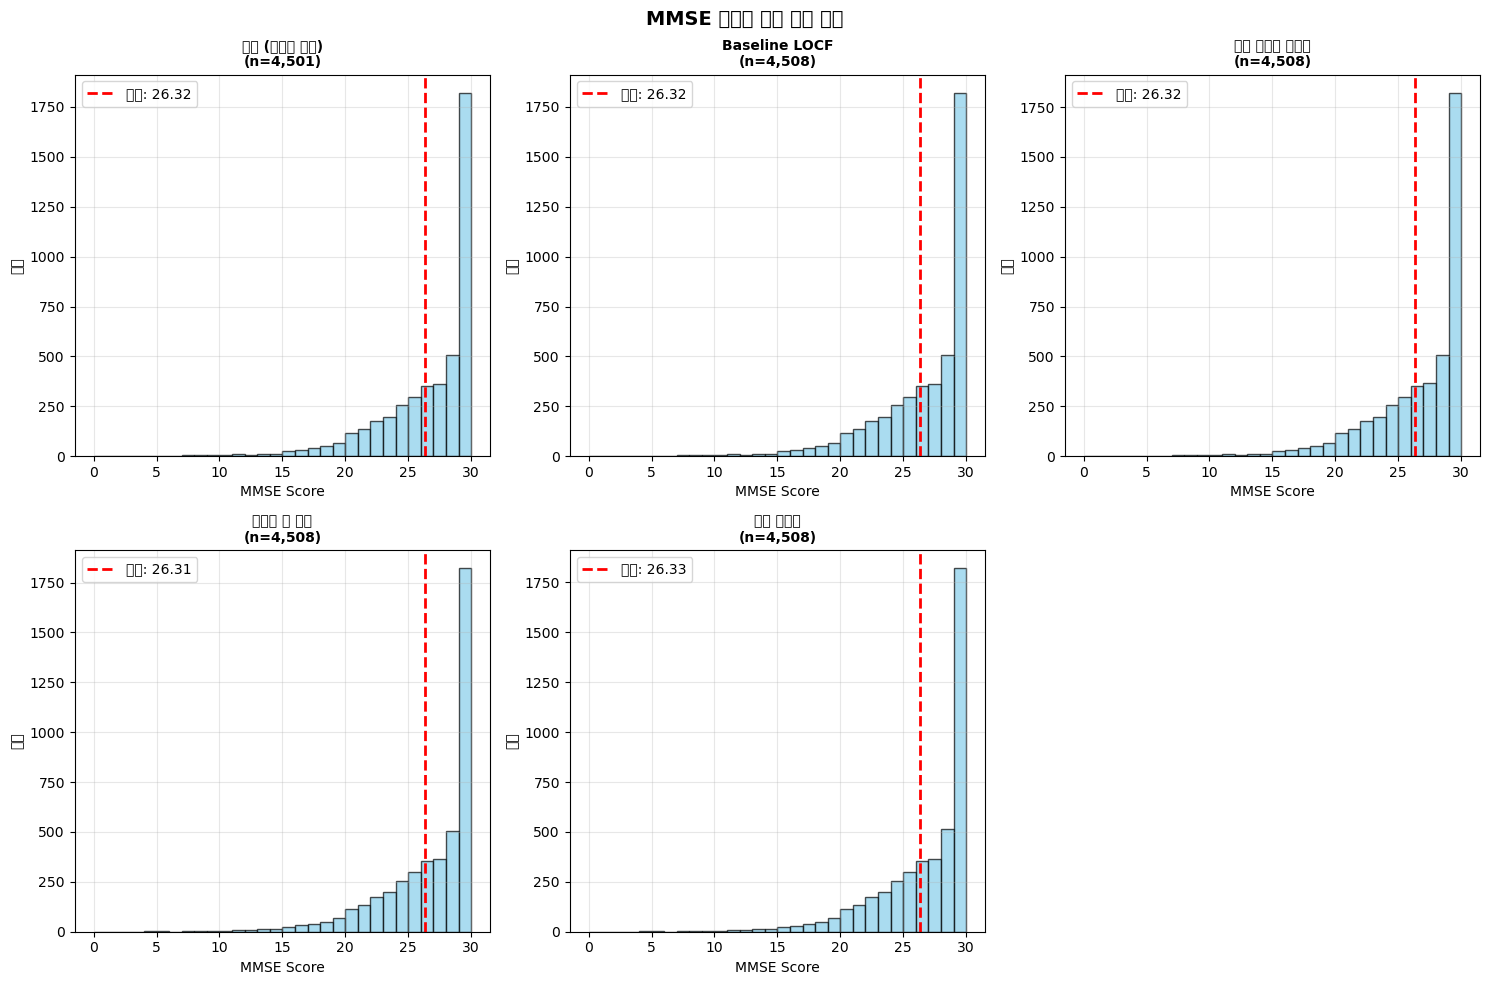


🏥 진단 그룹별 평균 비교:

그룹         원본         Baseline   그룹별        피험자내       전체중앙      
----------------------------------------------------------------------
CN         28.94      28.94      28.94      28.94      28.94     
MCI        26.04      26.05      26.05      26.03      26.05     
AD         21.82      21.81      21.82      21.80      21.83     


In [12]:
print("="*50)
print("결측치 처리 방법 비교 (MMSE 예시)")
print("="*50)

# MMSE를 예시로 여러 방법 비교
if 'MMSE' in df.columns:
    test_var = 'MMSE'
    
    # 원본 통계
    print(f"\n📊 원본 {test_var} 통계:")
    print(f"   - 총 데이터: {len(df):,}개")
    print(f"   - 결측치: {df[test_var].isnull().sum():,}개 ({df[test_var].isnull().sum()/len(df)*100:.2f}%)")
    print(f"   - 유효 데이터: {df[test_var].notna().sum():,}개")
    print(f"   - 평균: {df[test_var].mean():.2f}")
    print(f"   - 표준편차: {df[test_var].std():.2f}")
    print(f"   - 중앙값: {df[test_var].median():.2f}")
    
    # 테스트용 데이터프레임 생성
    df_test = df[['Subject', 'Group-RS:InitialDX', 'Visit', 'Years_bl', test_var, f'{test_var}_bl']].copy()
    
    # 방법 1: Baseline 값으로 대체 (LOCF)
    df_test['MMSE_baseline_fill'] = df_test[test_var].fillna(df_test[f'{test_var}_bl'])
    
    # 방법 2: 진단 그룹별 중앙값 대체
    group_medians = df_test.groupby('Group-RS:InitialDX')[test_var].median()
    df_test['MMSE_group_fill'] = df_test.apply(
        lambda row: group_medians[row['Group-RS:InitialDX']] if pd.isna(row[test_var]) else row[test_var],
        axis=1
    )
    
    # 방법 3: 피험자 내 보간 (forward fill + backward fill)
    df_test = df_test.sort_values(['Subject', 'Years_bl'])
    df_test['MMSE_subject_fill'] = df_test.groupby('Subject')[test_var].fillna(method='ffill').fillna(method='bfill')
    
    # 방법 4: 전체 중앙값 대체
    df_test['MMSE_median_fill'] = df_test[test_var].fillna(df_test[test_var].median())
    
    # 결과 비교
    print(f"\n📈 결측치 처리 결과 비교:")
    print(f"\n{'방법':<30} {'완성도':<10} {'평균':<10} {'표준편차':<10} {'중앙값':<10}")
    print("-" * 70)
    
    methods = {
        '원본 (결측치 제외)': test_var,
        'Baseline LOCF': 'MMSE_baseline_fill',
        '진단 그룹별 중앙값': 'MMSE_group_fill',
        '피험자 내 보간': 'MMSE_subject_fill',
        '전체 중앙값': 'MMSE_median_fill'
    }
    
    for method_name, col_name in methods.items():
        completeness = df_test[col_name].notna().sum() / len(df_test) * 100
        mean_val = df_test[col_name].mean()
        std_val = df_test[col_name].std()
        median_val = df_test[col_name].median()
        print(f"{method_name:<30} {completeness:>6.2f}%   {mean_val:>7.2f}    {std_val:>7.2f}      {median_val:>7.2f}")
    
    # 방법별 분포 시각화
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for idx, (method_name, col_name) in enumerate(methods.items()):
        axes[idx].hist(df_test[col_name].dropna(), bins=30, color='skyblue', edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'{method_name}\n(n={df_test[col_name].notna().sum():,})', fontsize=10, fontweight='bold')
        axes[idx].set_xlabel('MMSE Score')
        axes[idx].set_ylabel('빈도')
        axes[idx].axvline(df_test[col_name].mean(), color='red', linestyle='--', linewidth=2, label=f'평균: {df_test[col_name].mean():.2f}')
        axes[idx].legend()
        axes[idx].grid(True, alpha=0.3)
    
    # 마지막 subplot 제거
    if len(methods) < 6:
        fig.delaxes(axes[5])
    
    plt.suptitle(f'{test_var} 결측치 처리 방법 비교', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # 진단 그룹별 비교
    print(f"\n🏥 진단 그룹별 평균 비교:")
    print(f"\n{'그룹':<10} {'원본':<10} {'Baseline':<10} {'그룹별':<10} {'피험자내':<10} {'전체중앙':<10}")
    print("-" * 70)
    
    for dx in ['CN', 'MCI', 'AD']:
        mask = df_test['Group-RS:InitialDX'] == dx
        row_data = [dx]
        for col in [test_var, 'MMSE_baseline_fill', 'MMSE_group_fill', 'MMSE_subject_fill', 'MMSE_median_fill']:
            mean_val = df_test.loc[mask, col].mean()
            row_data.append(f"{mean_val:.2f}")
        print(f"{row_data[0]:<10} {row_data[1]:<10} {row_data[2]:<10} {row_data[3]:<10} {row_data[4]:<10} {row_data[5]:<10}")

else:
    print(f"⚠️ {test_var} 컬럼을 찾을 수 없습니다.")

고급 결측치 처리 방법 (KNN, MICE)

📋 테스트 변수: MMSE, ADAS11, CDRSB, FAQ, Age, PTEDUCAT

📊 원본 데이터 결측치:
   - MMSE           :  0.16%
   - ADAS11         :  0.42%
   - CDRSB          :  0.75%
   - FAQ            :  0.67%
   - Age            :  0.00%
   - PTEDUCAT       :  0.00%

🔧 KNN Imputation 수행 중... (k=5)
🔧 MICE Imputation 수행 중...

📈 고급 방법 결과 비교 (MMSE 기준):

방법                   완성도        평균         표준편차       중앙값       
------------------------------------------------------------
원본                    99.84%     26.32       4.02        28.00
KNN (k=5)            100.00%     26.31       4.04        28.00
MICE                 100.00%     26.31       4.05        28.00


/var/folders/zb/yqyg0k1554l0vj7zf6mzbm240000gn/T/ipykernel_62296/1699279523.py:92: UserWarning: Glyph 48712 (\N{HANGUL SYLLABLE BIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zb/yqyg0k1554l0vj7zf6mzbm240000gn/T/ipykernel_62296/1699279523.py:92: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zb/yqyg0k1554l0vj7zf6mzbm240000gn/T/ipykernel_62296/1699279523.py:92: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zb/yqyg0k1554l0vj7zf6mzbm240000gn/T/ipykernel_62296/1699279523.py:92: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zb/yqyg0k1554l0vj7zf6mzbm240000gn/T/ipykernel_62296/1699279523.py:92: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zb/yqyg0k1554l0vj7zf6mzbm240000gn/T/ipykern

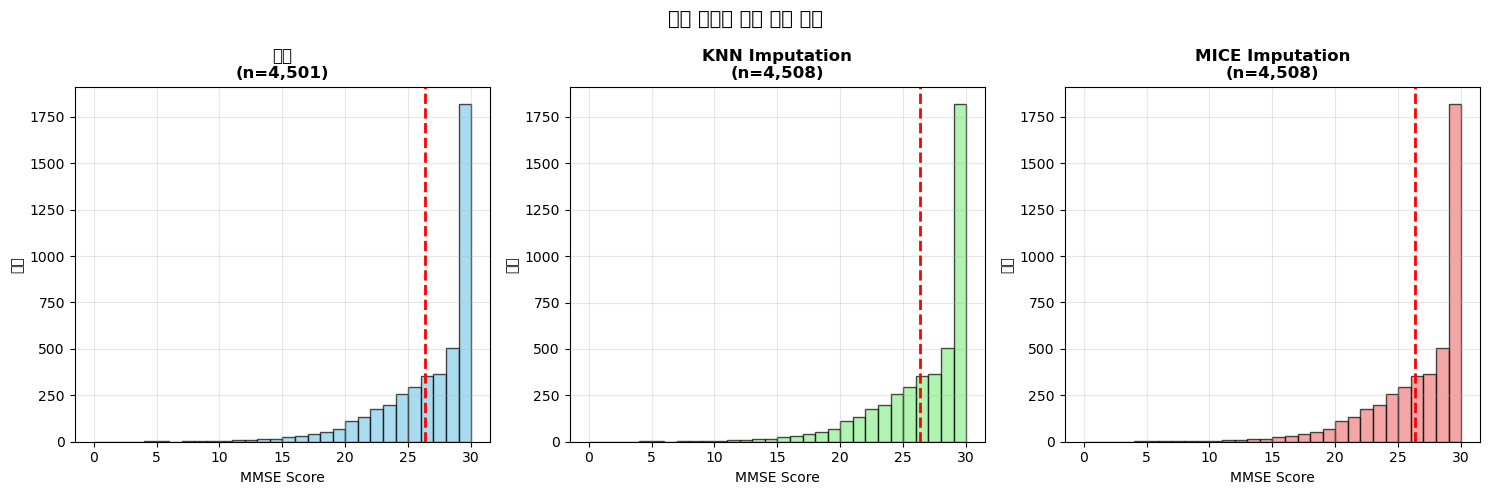


📊 모든 변수 통계 비교:

변수              방법         평균         표준편차      
---------------------------------------------

MMSE
                원본           26.32       4.02
                KNN          26.31       4.04
                MICE         26.31       4.05

ADAS11
                원본           11.97       8.81
                KNN          12.01       8.86
                MICE         12.02       8.87

CDRSB
                원본            2.13       2.65
                KNN           2.13       2.66
                MICE          2.13       2.66


In [13]:
print("="*50)
print("고급 결측치 처리 방법 (KNN, MICE)")
print("="*50)

try:
    from sklearn.impute import KNNImputer
    from sklearn.experimental import enable_iterative_imputer
    from sklearn.impute import IterativeImputer
    sklearn_available = True
except ImportError:
    sklearn_available = False
    print("\n⚠️ scikit-learn이 설치되어 있지 않습니다.")
    print("   설치 명령어: pip install scikit-learn")

if sklearn_available:
    # 테스트용 주요 임상 변수 선택
    clinical_features = ['MMSE', 'ADAS11', 'CDRSB', 'FAQ', 'Age', 'PTEDUCAT']
    existing_features = [f for f in clinical_features if f in df.columns]
    
    print(f"\n📋 테스트 변수: {', '.join(existing_features)}")
    
    # 테스트 데이터 준비
    df_impute_test = df[existing_features].copy()
    
    print(f"\n📊 원본 데이터 결측치:")
    for col in existing_features:
        missing_pct = df_impute_test[col].isnull().sum() / len(df_impute_test) * 100
        print(f"   - {col:15s}: {missing_pct:5.2f}%")
    
    # KNN Imputation
    print(f"\n🔧 KNN Imputation 수행 중... (k=5)")
    knn_imputer = KNNImputer(n_neighbors=5, weights='distance')
    df_knn = pd.DataFrame(
        knn_imputer.fit_transform(df_impute_test),
        columns=existing_features,
        index=df_impute_test.index
    )
    
    # MICE (Iterative Imputation)
    print(f"🔧 MICE Imputation 수행 중...")
    mice_imputer = IterativeImputer(max_iter=10, random_state=42)
    df_mice = pd.DataFrame(
        mice_imputer.fit_transform(df_impute_test),
        columns=existing_features,
        index=df_impute_test.index
    )
    
    # 결과 비교
    print(f"\n📈 고급 방법 결과 비교 (MMSE 기준):")
    if 'MMSE' in existing_features:
        print(f"\n{'방법':<20} {'완성도':<10} {'평균':<10} {'표준편차':<10} {'중앙값':<10}")
        print("-" * 60)
        
        # 원본
        completeness = df_impute_test['MMSE'].notna().sum() / len(df_impute_test) * 100
        print(f"{'원본':<20} {completeness:>6.2f}%   {df_impute_test['MMSE'].mean():>7.2f}    {df_impute_test['MMSE'].std():>7.2f}      {df_impute_test['MMSE'].median():>7.2f}")
        
        # KNN
        print(f"{'KNN (k=5)':<20} {100.0:>6.2f}%   {df_knn['MMSE'].mean():>7.2f}    {df_knn['MMSE'].std():>7.2f}      {df_knn['MMSE'].median():>7.2f}")
        
        # MICE
        print(f"{'MICE':<20} {100.0:>6.2f}%   {df_mice['MMSE'].mean():>7.2f}    {df_mice['MMSE'].std():>7.2f}      {df_mice['MMSE'].median():>7.2f}")
        
        # 시각화
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        
        # 원본
        axes[0].hist(df_impute_test['MMSE'].dropna(), bins=30, color='skyblue', edgecolor='black', alpha=0.7)
        axes[0].set_title(f'원본\n(n={df_impute_test["MMSE"].notna().sum():,})', fontweight='bold')
        axes[0].set_xlabel('MMSE Score')
        axes[0].set_ylabel('빈도')
        axes[0].axvline(df_impute_test['MMSE'].mean(), color='red', linestyle='--', linewidth=2)
        axes[0].grid(True, alpha=0.3)
        
        # KNN
        axes[1].hist(df_knn['MMSE'], bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
        axes[1].set_title(f'KNN Imputation\n(n={len(df_knn):,})', fontweight='bold')
        axes[1].set_xlabel('MMSE Score')
        axes[1].set_ylabel('빈도')
        axes[1].axvline(df_knn['MMSE'].mean(), color='red', linestyle='--', linewidth=2)
        axes[1].grid(True, alpha=0.3)
        
        # MICE
        axes[2].hist(df_mice['MMSE'], bins=30, color='lightcoral', edgecolor='black', alpha=0.7)
        axes[2].set_title(f'MICE Imputation\n(n={len(df_mice):,})', fontweight='bold')
        axes[2].set_xlabel('MMSE Score')
        axes[2].set_ylabel('빈도')
        axes[2].axvline(df_mice['MMSE'].mean(), color='red', linestyle='--', linewidth=2)
        axes[2].grid(True, alpha=0.3)
        
        plt.suptitle('고급 결측치 처리 방법 비교', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
    
    # 모든 변수에 대한 통계 비교
    print(f"\n📊 모든 변수 통계 비교:")
    print(f"\n{'변수':<15} {'방법':<10} {'평균':<10} {'표준편차':<10}")
    print("-" * 45)
    
    for var in existing_features[:3]:  # 처음 3개만 출력
        print(f"\n{var}")
        print(f"{'':15} {'원본':<10} {df_impute_test[var].mean():>7.2f}    {df_impute_test[var].std():>7.2f}")
        print(f"{'':15} {'KNN':<10} {df_knn[var].mean():>7.2f}    {df_knn[var].std():>7.2f}")
        print(f"{'':15} {'MICE':<10} {df_mice[var].mean():>7.2f}    {df_mice[var].std():>7.2f}")

else:
    print("\n💡 KNN과 MICE를 사용하려면 scikit-learn을 설치해주세요:")
    print("   pip install scikit-learn")

In [14]:
print("="*50)
print("결측치 50% 미만 데이터 불러오기")
print("="*50)

# 결측치 50% 미만 데이터 로드
df_low_missing = pd.read_csv('/Users/othree/Cognitive Reserve Modeling/Data/ADNI_low_missing_50percent.csv')

print(f"\n✅ 데이터 로드 완료!")
print(f"   - 행 수: {df_low_missing.shape[0]:,}")
print(f"   - 열 수: {df_low_missing.shape[1]}")

# 결측치 현황 확인
missing_info = pd.DataFrame({
    '결측치 개수': df_low_missing.isnull().sum(),
    '결측치 비율(%)': (df_low_missing.isnull().sum() / len(df_low_missing) * 100).round(2)
})
missing_info = missing_info[missing_info['결측치 개수'] > 0].sort_values('결측치 비율(%)', ascending=False)

print(f"\n📊 결측치가 있는 컬럼: {len(missing_info)}개")
print(missing_info.head(20))

결측치 50% 미만 데이터 불러오기

✅ 데이터 로드 완료!
   - 행 수: 4,508
   - 열 수: 88

📊 결측치가 있는 컬럼: 47개
                결측치 개수  결측치 비율(%)
MOCA              2916      64.69
ABETA_bl          1748      38.78
TAU_bl            1748      38.78
PTAU_bl           1748      38.78
DIGITSCOR         1669      37.02
FDG_bl            1640      36.38
DIGITSCOR_bl      1259      27.93
LDELTOTAL         1245      27.62
MidTemp            935      20.74
Fusiform           935      20.74
Entorhinal         935      20.74
Entorhinal_bl      766      16.99
MidTemp_bl         766      16.99
Fusiform_bl        766      16.99
Hippocampus        749      16.61
Hippocampus_bl     744      16.50
Ventricles         250       5.55
FLDSTRENG_bl       248       5.50
TRABSCOR           210       4.66
FLDSTRENG          185       4.10


In [15]:
print("="*50)
print("단계적 결측치 처리 (Hierarchical Imputation)")
print("="*50)

# 데이터 복사본 생성
df_imputed = df_low_missing.copy()

# 필요한 컬럼들 확인
required_cols = ['Subject', 'Group-RS:InitialDX', 'Years_bl']
for col in required_cols:
    if col not in df_imputed.columns:
        print(f"⚠️ 필수 컬럼 '{col}'이 없습니다. 원본 데이터에서 가져옵니다.")
        if col in df.columns:
            df_imputed[col] = df[col]

# 숫자형 컬럼과 범주형 컬럼 분리
numeric_cols = df_imputed.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df_imputed.select_dtypes(include=['object']).columns.tolist()

print(f"\n📊 컬럼 타입 분류:")
print(f"   - 숫자형 컬럼: {len(numeric_cols)}개")
print(f"   - 범주형 컬럼: {len(categorical_cols)}개")

# 숫자형 컬럼에서만 결측치 처리 대상 선택
missing_ratio = (df_imputed[numeric_cols].isnull().sum() / len(df_imputed) * 100)
cols_above_10 = missing_ratio[missing_ratio >= 10].index.tolist()
cols_below_10 = missing_ratio[(missing_ratio > 0) & (missing_ratio < 10)].index.tolist()

# 필수 컬럼 제외
cols_above_10 = [col for col in cols_above_10 if col not in required_cols]
cols_below_10 = [col for col in cols_below_10 if col not in required_cols]

print(f"\n📊 결측치 분류 (숫자형 컬럼만):")
print(f"   - 결측치 10% 이상: {len(cols_above_10)}개 → 단계적 처리")
print(f"   - 결측치 10% 미만: {len(cols_below_10)}개 → 그룹별 중앙값만")

# 범주형 컬럼의 결측치는 최빈값으로 처리
categorical_missing = df_imputed[categorical_cols].isnull().sum()
categorical_missing = categorical_missing[categorical_missing > 0]

if len(categorical_missing) > 0:
    print(f"\n📝 범주형 컬럼 결측치 (최빈값으로 처리): {len(categorical_missing)}개")
    for col in categorical_missing.index:
        mode_value = df_imputed[col].mode()[0] if len(df_imputed[col].mode()) > 0 else None
        if mode_value is not None:
            df_imputed[col] = df_imputed[col].fillna(mode_value)
            print(f"   - {col}: 최빈값 '{mode_value}'로 채움")

# 처리 전 통계 저장
imputation_log = []

print(f"\n" + "="*70)
print("결측치 10% 이상 변수 - 단계적 처리")
print("="*70)

# 데이터를 Subject와 Years_bl로 정렬 (시계열 순서)
df_imputed = df_imputed.sort_values(['Subject', 'Years_bl'])

for col in cols_above_10:
    print(f"\n🔧 처리 중: {col}")
    
    original_missing = df_imputed[col].isnull().sum()
    print(f"   원본 결측치: {original_missing:,}개 ({original_missing/len(df_imputed)*100:.2f}%)")
    
    # 1단계: 피험자 내 보간 (forward fill + backward fill)
    df_imputed[col] = df_imputed.groupby('Subject')[col].ffill().bfill()
    after_step1 = df_imputed[col].isnull().sum()
    step1_filled = original_missing - after_step1
    print(f"   1단계 (피험자 내 보간): {step1_filled:,}개 채움 → 남은 결측치: {after_step1:,}개")
    
    # 2단계: Baseline 값 사용
    baseline_col = f"{col}_bl"
    if baseline_col in df_imputed.columns:
        df_imputed[col] = df_imputed[col].fillna(df_imputed[baseline_col])
        after_step2 = df_imputed[col].isnull().sum()
        step2_filled = after_step1 - after_step2
        print(f"   2단계 (Baseline 값): {step2_filled:,}개 채움 → 남은 결측치: {after_step2:,}개")
    else:
        after_step2 = after_step1
        step2_filled = 0
        print(f"   2단계 (Baseline 값): Baseline 컬럼 없음")
    
    # 3단계: 진단 그룹별 중앙값
    if 'Group-RS:InitialDX' in df_imputed.columns:
        group_medians = df_imputed.groupby('Group-RS:InitialDX')[col].median()
        mask = df_imputed[col].isnull()
        df_imputed.loc[mask, col] = df_imputed.loc[mask, 'Group-RS:InitialDX'].map(group_medians)
        after_step3 = df_imputed[col].isnull().sum()
        step3_filled = after_step2 - after_step3
        print(f"   3단계 (그룹별 중앙값): {step3_filled:,}개 채움 → 남은 결측치: {after_step3:,}개")
    else:
        after_step3 = after_step2
        step3_filled = 0
    
    # 로그 저장
    imputation_log.append({
        '변수': col,
        '원본_결측치': original_missing,
        '1단계_채움': step1_filled,
        '2단계_채움': step2_filled,
        '3단계_채움': step3_filled,
        '최종_결측치': after_step3,
        '처리율(%)': ((original_missing - after_step3) / original_missing * 100) if original_missing > 0 else 0
    })

print(f"\n" + "="*70)
print("결측치 10% 미만 변수 - 그룹별 중앙값 처리")
print("="*70)

for col in cols_below_10:
    print(f"\n🔧 처리 중: {col}")
    
    original_missing = df_imputed[col].isnull().sum()
    print(f"   원본 결측치: {original_missing:,}개 ({original_missing/len(df_imputed)*100:.2f}%)")
    
    # 진단 그룹별 중앙값
    if 'Group-RS:InitialDX' in df_imputed.columns:
        group_medians = df_imputed.groupby('Group-RS:InitialDX')[col].median()
        mask = df_imputed[col].isnull()
        df_imputed.loc[mask, col] = df_imputed.loc[mask, 'Group-RS:InitialDX'].map(group_medians)
        after_fill = df_imputed[col].isnull().sum()
        filled = original_missing - after_fill
        print(f"   그룹별 중앙값: {filled:,}개 채움 → 남은 결측치: {after_fill:,}개")
        
        imputation_log.append({
            '변수': col,
            '원본_결측치': original_missing,
            '1단계_채움': 0,
            '2단계_채움': 0,
            '3단계_채움': filled,
            '최종_결측치': after_fill,
            '처리율(%)': ((original_missing - after_fill) / original_missing * 100) if original_missing > 0 else 0
        })

# 결과 요약
print(f"\n" + "="*70)
print("결측치 처리 요약")
print("="*70)

log_df = pd.DataFrame(imputation_log)
print(f"\n총 처리된 변수: {len(log_df)}개")
print(f"\n{log_df.to_string(index=False)}")

print(f"\n📊 전체 통계:")
print(f"   - 총 결측치 (처리 전): {log_df['원본_결측치'].sum():,}개")
print(f"   - 총 결측치 (처리 후): {log_df['최종_결측치'].sum():,}개")
print(f"   - 처리된 결측치: {log_df['원본_결측치'].sum() - log_df['최종_결측치'].sum():,}개")
if log_df['원본_결측치'].sum() > 0:
    print(f"   - 전체 처리율: {((log_df['원본_결측치'].sum() - log_df['최종_결측치'].sum()) / log_df['원본_결측치'].sum() * 100):.2f}%")

단계적 결측치 처리 (Hierarchical Imputation)

📊 컬럼 타입 분류:
   - 숫자형 컬럼: 60개
   - 범주형 컬럼: 28개

📊 결측치 분류 (숫자형 컬럼만):
   - 결측치 10% 이상: 13개 → 단계적 처리
   - 결측치 10% 미만: 28개 → 그룹별 중앙값만

📝 범주형 컬럼 결측치 (최빈값으로 처리): 6개
   - FLDSTRENG: 최빈값 '1.5 Tesla MRI'로 채움
   - FLDSTRENG_bl: 최빈값 '1.5 Tesla MRI'로 채움
   - FSVERSION_bl: 최빈값 'Cross-Sectional FreeSurfer (FreeSurfer Version 4.3)'로 채움
   - ABETA_bl: 최빈값 '>1700'로 채움
   - TAU_bl: 최빈값 '107.3'로 채움
   - PTAU_bl: 최빈값 '29.77'로 채움

결측치 10% 이상 변수 - 단계적 처리

🔧 처리 중: LDELTOTAL
   원본 결측치: 1,245개 (27.62%)
   1단계 (피험자 내 보간): 1,245개 채움 → 남은 결측치: 0개
   2단계 (Baseline 값): Baseline 컬럼 없음
   3단계 (그룹별 중앙값): 0개 채움 → 남은 결측치: 0개

🔧 처리 중: DIGITSCOR
   원본 결측치: 1,669개 (37.02%)
   1단계 (피험자 내 보간): 1,645개 채움 → 남은 결측치: 24개
   2단계 (Baseline 값): 0개 채움 → 남은 결측치: 24개
   3단계 (그룹별 중앙값): 24개 채움 → 남은 결측치: 0개

🔧 처리 중: Hippocampus
   원본 결측치: 749개 (16.61%)
   1단계 (피험자 내 보간): 749개 채움 → 남은 결측치: 0개
   2단계 (Baseline 값): 0개 채움 → 남은 결측치: 0개
   3단계 (그룹별 중앙값): 0개 채움 → 남은 결측치: 0개

🔧 처리 중: Entorhinal
   원본 결측치: 935

결측치 처리 결과 시각화 및 저장


/var/folders/zb/yqyg0k1554l0vj7zf6mzbm240000gn/T/ipykernel_62296/1777738635.py:77: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zb/yqyg0k1554l0vj7zf6mzbm240000gn/T/ipykernel_62296/1777738635.py:77: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zb/yqyg0k1554l0vj7zf6mzbm240000gn/T/ipykernel_62296/1777738635.py:77: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zb/yqyg0k1554l0vj7zf6mzbm240000gn/T/ipykernel_62296/1777738635.py:77: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zb/yqyg0k1554l0vj7zf6mzbm240000gn/T/ipykernel_62296/1777738635.py:77: UserWarning: Glyph 52824 (\N{HANGUL SYLLABLE CI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zb/yqyg0k1554l0vj7zf6mzbm240000gn/T/ipy

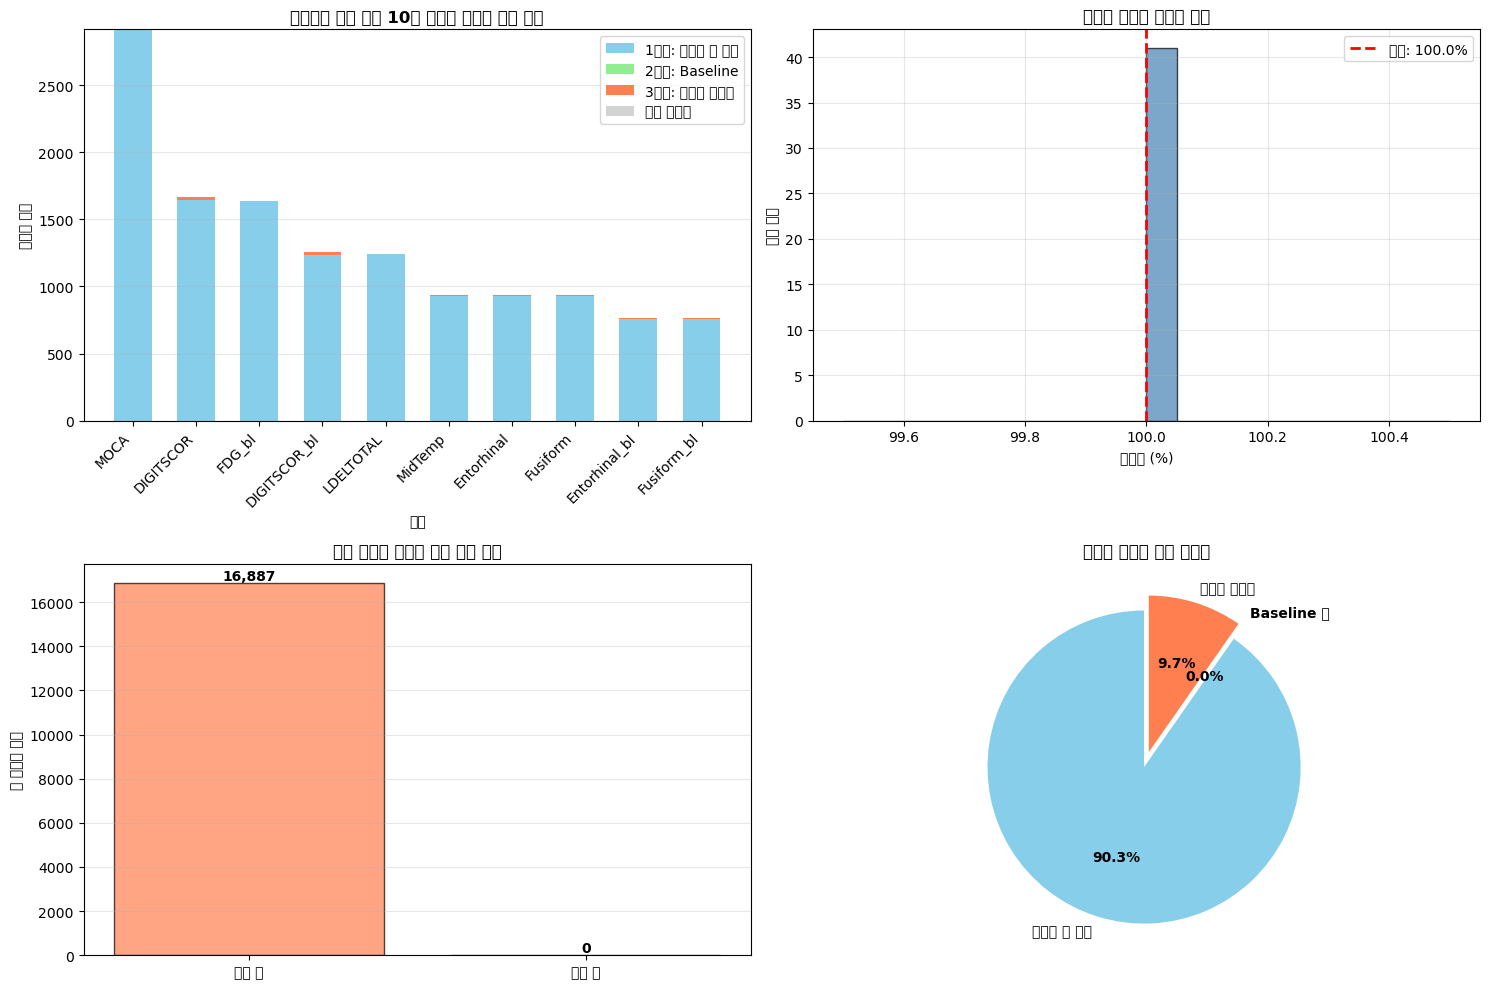


📊 처리 후 최종 결측치 현황:

✅ 모든 결측치가 처리되었습니다!

💾 처리된 데이터 저장 완료!
   - 파일 경로: /Users/othree/Cognitive Reserve Modeling/Data/ADNI_imputed_hierarchical.csv
   - 행 수: 4,508
   - 열 수: 88
   - 남은 결측치: 0개

📝 처리 로그 저장 완료!
   - 파일 경로: /Users/othree/Cognitive Reserve Modeling/Data/ADNI_imputation_log.csv


In [16]:
print("="*50)
print("결측치 처리 결과 시각화 및 저장")
print("="*50)

# 1. 단계별 기여도 시각화
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 상위 10개 변수의 단계별 처리 현황
log_df_sorted = log_df.sort_values('원본_결측치', ascending=False).head(10)

ax1 = axes[0, 0]
x_pos = range(len(log_df_sorted))
width = 0.6

# 누적 막대 그래프
ax1.bar(x_pos, log_df_sorted['1단계_채움'], width, label='1단계: 피험자 내 보간', color='skyblue')
ax1.bar(x_pos, log_df_sorted['2단계_채움'], width, bottom=log_df_sorted['1단계_채움'], 
        label='2단계: Baseline', color='lightgreen')
ax1.bar(x_pos, log_df_sorted['3단계_채움'], width, 
        bottom=log_df_sorted['1단계_채움'] + log_df_sorted['2단계_채움'],
        label='3단계: 그룹별 중앙값', color='coral')
ax1.bar(x_pos, log_df_sorted['최종_결측치'], width,
        bottom=log_df_sorted['1단계_채움'] + log_df_sorted['2단계_채움'] + log_df_sorted['3단계_채움'],
        label='남은 결측치', color='lightgray')

ax1.set_xlabel('변수')
ax1.set_ylabel('결측치 개수')
ax1.set_title('결측치가 많은 상위 10개 변수의 단계별 처리 현황', fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(log_df_sorted['변수'], rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# 처리율 분포
ax2 = axes[0, 1]
ax2.hist(log_df['처리율(%)'], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
ax2.set_xlabel('처리율 (%)')
ax2.set_ylabel('변수 개수')
ax2.set_title('변수별 결측치 처리율 분포', fontweight='bold')
ax2.axvline(log_df['처리율(%)'].mean(), color='red', linestyle='--', linewidth=2, 
            label=f'평균: {log_df["처리율(%)"].mean():.1f}%')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 전체 결측치 처리 전후 비교
ax3 = axes[1, 0]
categories = ['처리 전', '처리 후']
values = [log_df['원본_결측치'].sum(), log_df['최종_결측치'].sum()]
colors = ['coral', 'lightgreen']
bars = ax3.bar(categories, values, color=colors, edgecolor='black', alpha=0.7)
ax3.set_ylabel('총 결측치 개수')
ax3.set_title('전체 데이터 결측치 처리 전후 비교', fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

# 막대 위에 값 표시
for bar, val in zip(bars, values):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(val):,}',
             ha='center', va='bottom', fontweight='bold')

# 단계별 기여도 파이 차트
ax4 = axes[1, 1]
step_contributions = [
    log_df['1단계_채움'].sum(),
    log_df['2단계_채움'].sum(),
    log_df['3단계_채움'].sum()
]
labels = ['피험자 내 보간', 'Baseline 값', '그룹별 중앙값']
colors_pie = ['skyblue', 'lightgreen', 'coral']
explode = (0.05, 0.05, 0.05)

ax4.pie(step_contributions, labels=labels, colors=colors_pie, autopct='%1.1f%%',
        startangle=90, explode=explode, textprops={'fontweight': 'bold'})
ax4.set_title('단계별 결측치 처리 기여도', fontweight='bold')

plt.tight_layout()
plt.show()

# 2. 최종 결측치 현황
print(f"\n📊 처리 후 최종 결측치 현황:")
final_missing = df_imputed.isnull().sum()
final_missing = final_missing[final_missing > 0].sort_values(ascending=False)

if len(final_missing) > 0:
    print(f"\n⚠️ 아직 결측치가 남아있는 컬럼: {len(final_missing)}개")
    print(final_missing)
else:
    print("\n✅ 모든 결측치가 처리되었습니다!")

# 3. 처리된 데이터 저장
output_path = '/Users/othree/Cognitive Reserve Modeling/Data/ADNI_imputed_hierarchical.csv'
df_imputed.to_csv(output_path, index=False)

print(f"\n💾 처리된 데이터 저장 완료!")
print(f"   - 파일 경로: {output_path}")
print(f"   - 행 수: {df_imputed.shape[0]:,}")
print(f"   - 열 수: {df_imputed.shape[1]}")
print(f"   - 남은 결측치: {df_imputed.isnull().sum().sum():,}개")

# 4. 처리 로그 저장
log_output_path = '/Users/othree/Cognitive Reserve Modeling/Data/ADNI_imputation_log.csv'
log_df.to_csv(log_output_path, index=False)
print(f"\n📝 처리 로그 저장 완료!")
print(f"   - 파일 경로: {log_output_path}")

In [17]:
print("="*50)
print("처리 전후 데이터 비교 (샘플)")
print("="*50)

# 주요 임상 변수들 선택
comparison_vars = ['MMSE', 'ADAS11', 'CDRSB', 'MOCA', 'FAQ']
existing_vars = [var for var in comparison_vars if var in df_low_missing.columns]

print(f"\n📊 주요 임상 변수 처리 전후 비교:")
print(f"\n{'변수':<15} {'처리 전 평균':<15} {'처리 후 평균':<15} {'처리 전 SD':<15} {'처리 후 SD':<15} {'결측치 감소':<15}")
print("-" * 90)

for var in existing_vars:
    before_mean = df_low_missing[var].mean()
    after_mean = df_imputed[var].mean()
    before_std = df_low_missing[var].std()
    after_std = df_imputed[var].std()
    before_missing = df_low_missing[var].isnull().sum()
    after_missing = df_imputed[var].isnull().sum()
    missing_reduction = before_missing - after_missing
    
    print(f"{var:<15} {before_mean:>12.2f}    {after_mean:>12.2f}    {before_std:>12.2f}    {after_std:>12.2f}    {missing_reduction:>12,}")

# 특정 피험자의 시계열 데이터 확인 (처리 전후)
if 'Subject' in df_imputed.columns and 'MMSE' in existing_vars:
    print(f"\n👤 특정 피험자의 MMSE 시계열 비교 (처리 전 → 후):")
    
    # 결측치가 있었지만 채워진 피험자 찾기
    sample_subjects = df_low_missing[df_low_missing['MMSE'].isnull()]['Subject'].unique()[:3]
    
    for subject_id in sample_subjects:
        print(f"\n   피험자 ID: {subject_id}")
        
        # 처리 전
        before_data = df_low_missing[df_low_missing['Subject'] == subject_id][['Years_bl', 'MMSE']].sort_values('Years_bl')
        # 처리 후
        after_data = df_imputed[df_imputed['Subject'] == subject_id][['Years_bl', 'MMSE']].sort_values('Years_bl')
        
        print(f"   {'Years_bl':<12} {'처리 전 MMSE':<15} {'처리 후 MMSE':<15} {'변경 여부':<10}")
        print("   " + "-" * 55)
        
        for idx, row in before_data.iterrows():
            years = row['Years_bl']
            before_val = row['MMSE']
            after_val = after_data[after_data['Years_bl'] == years]['MMSE'].values[0] if len(after_data[after_data['Years_bl'] == years]) > 0 else None
            
            if pd.isna(before_val):
                before_str = "결측"
                after_str = f"{after_val:.1f}" if not pd.isna(after_val) else "결측"
                changed = "✅ 채움" if not pd.isna(after_val) else "❌ 미처리"
            else:
                before_str = f"{before_val:.1f}"
                after_str = f"{after_val:.1f}" if not pd.isna(after_val) else "결측"
                changed = "동일"
            
            print(f"   {years:<12.2f} {before_str:<15} {after_str:<15} {changed:<10}")
        
        print()

# 진단 그룹별 처리 전후 비교
if 'Group-RS:InitialDX' in df_imputed.columns and len(existing_vars) > 0:
    print(f"\n🏥 진단 그룹별 MMSE 평균 비교 (처리 전 → 후):")
    if 'MMSE' in existing_vars:
        print(f"\n{'그룹':<10} {'처리 전 평균':<15} {'처리 후 평균':<15} {'변화':<15}")
        print("-" * 55)
        
        for dx in ['CN', 'MCI', 'AD']:
            mask = df_imputed['Group-RS:InitialDX'] == dx
            before_mean = df_low_missing.loc[mask, 'MMSE'].mean()
            after_mean = df_imputed.loc[mask, 'MMSE'].mean()
            change = after_mean - before_mean
            
            print(f"{dx:<10} {before_mean:>12.2f}    {after_mean:>12.2f}    {change:>+12.3f}")

print(f"\n✅ 결측치 처리 완료!")
print(f"\n생성된 파일:")
print(f"   1. ADNI_imputed_hierarchical.csv - 단계적 처리가 완료된 데이터")
print(f"   2. ADNI_imputation_log.csv - 변수별 처리 로그")

처리 전후 데이터 비교 (샘플)

📊 주요 임상 변수 처리 전후 비교:

변수              처리 전 평균         처리 후 평균         처리 전 SD         처리 후 SD         결측치 감소         
------------------------------------------------------------------------------------------
MMSE                   26.32           26.32            4.02            4.01               7
ADAS11                 11.97           11.98            8.81            8.80              19
CDRSB                   2.13            2.12            2.65            2.65              34
MOCA                   22.92           22.72            5.51            5.28           2,916
FAQ                     5.88            5.86            7.97            7.95              30

👤 특정 피험자의 MMSE 시계열 비교 (처리 전 → 후):

   피험자 ID: 098_S_0667
   Years_bl     처리 전 MMSE       처리 후 MMSE       변경 여부     
   -------------------------------------------------------
   0.00         28.0            28.0            동일        
   0.57         23.0            23.0            동일        
   1.02      

In [18]:
print("="*70)
print("MCAR 테스트 준비: 완전한 데이터 선택")
print("="*70)

# 테스트할 주요 임상 변수들
test_variables = ['MMSE', 'ADAS11', 'CDRSB', 'FAQ']
existing_test_vars = [v for v in test_variables if v in df.columns]

print(f"\n테스트 변수: {', '.join(existing_test_vars)}")

# 필수 컬럼들
required_for_test = ['Subject', 'Group-RS:InitialDX', 'Years_bl'] + existing_test_vars

# 테스트 변수에 대해 결측치가 없는 행만 선택
df_complete = df[required_for_test].dropna(subset=existing_test_vars).copy()

print(f"\n원본 데이터: {len(df):,}행")
print(f"완전한 데이터 (결측치 없음): {len(df_complete):,}행")
print(f"선택된 비율: {len(df_complete)/len(df)*100:.1f}%")

# 각 변수의 통계
print(f"\n완전한 데이터의 기술 통계:")
print(df_complete[existing_test_vars].describe())

MCAR 테스트 준비: 완전한 데이터 선택

테스트 변수: MMSE, ADAS11, CDRSB, FAQ

원본 데이터: 4,508행
완전한 데이터 (결측치 없음): 4,442행
선택된 비율: 98.5%

완전한 데이터의 기술 통계:
              MMSE       ADAS11        CDRSB          FAQ
count  4442.000000  4442.000000  4442.000000  4442.000000
mean     26.331833    11.959532     2.112112     5.836335
std       3.983553     8.704592     2.625639     7.918750
min       0.000000     0.000000     0.000000     0.000000
25%      24.000000     5.670000     0.000000     0.000000
50%      28.000000     9.670000     1.000000     1.000000
75%      29.000000    16.330000     3.500000    10.000000
max      30.000000    66.000000    17.000000    30.000000


In [19]:
print("="*70)
print("MCAR 테스트: 무작위 결측치 생성 및 보간")
print("="*70)

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 테스트할 결측치 비율들
missing_rates = [0.2, 0.3, 0.4]  # 20%, 30%, 40%

# 결과 저장용
mcar_results = []

# 랜덤 시드 설정 (재현성)
np.random.seed(42)

for missing_rate in missing_rates:
    print(f"\n" + "="*70)
    print(f"결측치 비율: {missing_rate*100:.0f}%")
    print("="*70)
    
    # 각 변수별로 테스트
    for var in existing_test_vars:
        print(f"\n🔬 테스트 변수: {var}")
        
        # 1. 원본 데이터 복사
        df_test = df_complete.copy()
        
        # 2. 무작위로 결측치 생성 (MCAR)
        n_samples = len(df_test)
        n_missing = int(n_samples * missing_rate)
        
        # 결측치로 만들 인덱스 무작위 선택
        missing_indices = np.random.choice(df_test.index, size=n_missing, replace=False)
        
        # 원본 값을 Subject, Years_bl과 함께 저장 (매칭용)
        ground_truth = df_test.loc[missing_indices, ['Subject', 'Years_bl', var]].copy()
        ground_truth.columns = ['Subject', 'Years_bl', 'original_value']
        
        # 결측치로 만들기
        df_test.loc[missing_indices, var] = np.nan
        
        print(f"   - 총 데이터: {n_samples:,}개")
        print(f"   - 생성된 결측치: {n_missing:,}개 ({missing_rate*100:.0f}%)")
        
        # 3. 단계적 보간 적용
        # 정렬
        df_test = df_test.sort_values(['Subject', 'Years_bl'])
        
        # 1단계: 피험자 내 보간
        df_test[f'{var}_imputed'] = df_test.groupby('Subject')[var].transform(lambda x: x.ffill().bfill())
        
        # 2단계: Baseline 값 (있다면)
        baseline_col = f"{var}_bl"
        if baseline_col in df.columns:
            # 원본 데이터에서 baseline 값 가져오기 (Subject별 첫 번째 값만)
            baseline_data = df.groupby('Subject')[baseline_col].first().reset_index()
            baseline_data.columns = ['Subject', f'{var}_baseline_value']
            
            df_test = df_test.merge(baseline_data, on='Subject', how='left')
            
            # baseline 값으로 채우기
            still_missing = df_test[f'{var}_imputed'].isnull()
            df_test.loc[still_missing, f'{var}_imputed'] = df_test.loc[still_missing, f'{var}_baseline_value']
        
        # 3단계: 진단 그룹별 중앙값
        # 원본 데이터에서 그룹별 중앙값 계산 (결측치 제외)
        group_medians = df_test.groupby('Group-RS:InitialDX')[var].median()
        mask = df_test[f'{var}_imputed'].isnull()
        df_test.loc[mask, f'{var}_imputed'] = df_test.loc[mask, 'Group-RS:InitialDX'].map(group_medians)
        
        # 4. 예측 값 추출 (Subject + Years_bl로 매칭)
        # ground_truth와 df_test를 Subject + Years_bl로 merge
        predictions = df_test[['Subject', 'Years_bl', f'{var}_imputed']].copy()
        predictions.columns = ['Subject', 'Years_bl', 'predicted_value']
        
        comparison = ground_truth.merge(predictions, on=['Subject', 'Years_bl'], how='inner')
        
        # 5. 결측치가 채워지지 않은 경우 제외
        valid_mask = comparison['predicted_value'].notna()
        comparison_valid = comparison[valid_mask]
        
        if len(comparison_valid) == 0:
            print(f"   ⚠️ 결측치를 채우지 못했습니다.")
            continue
        
        original_valid = comparison_valid['original_value'].values
        predicted_valid = comparison_valid['predicted_value'].values
        
        # 6. 성능 평가
        mae = mean_absolute_error(original_valid, predicted_valid)
        rmse = np.sqrt(mean_squared_error(original_valid, predicted_valid))
        r2 = r2_score(original_valid, predicted_valid)
        
        # 정확도 계산 (±1점 이내, ±2점 이내)
        errors = np.abs(original_valid - predicted_valid)
        accuracy_1 = (errors <= 1).sum() / len(errors) * 100
        accuracy_2 = (errors <= 2).sum() / len(errors) * 100
        
        print(f"   - 복원 성공: {len(predicted_valid):,}/{n_missing:,} ({len(predicted_valid)/n_missing*100:.1f}%)")
        print(f"   - MAE:  {mae:.3f}")
        print(f"   - RMSE: {rmse:.3f}")
        print(f"   - R²:   {r2:.3f}")
        print(f"   - ±1점 정확도: {accuracy_1:.1f}%")
        print(f"   - ±2점 정확도: {accuracy_2:.1f}%")
        
        # 결과 저장
        mcar_results.append({
            '변수': var,
            '결측치_비율': f"{missing_rate*100:.0f}%",
            'MAE': mae,
            'RMSE': rmse,
            'R²': r2,
            '±1점_정확도(%)': accuracy_1,
            '±2점_정확도(%)': accuracy_2,
            '복원_성공률(%)': len(predicted_valid)/n_missing*100
        })

# 결과 요약
print(f"\n" + "="*70)
print("MCAR 테스트 결과 요약")
print("="*70)

results_df = pd.DataFrame(mcar_results)
print(f"\n{results_df.to_string(index=False)}")

MCAR 테스트: 무작위 결측치 생성 및 보간

결측치 비율: 20%

🔬 테스트 변수: MMSE
   - 총 데이터: 4,442개
   - 생성된 결측치: 888개 (20%)


   - 복원 성공: 888/888 (100.0%)
   - MAE:  1.794
   - RMSE: 2.797
   - R²:   0.558
   - ±1점 정확도: 59.8%
   - ±2점 정확도: 77.0%

🔬 테스트 변수: ADAS11
   - 총 데이터: 4,442개
   - 생성된 결측치: 888개 (20%)
   - 복원 성공: 888/888 (100.0%)
   - MAE:  3.131
   - RMSE: 4.660
   - R²:   0.743
   - ±1점 정확도: 31.4%
   - ±2점 정확도: 51.4%

🔬 테스트 변수: CDRSB
   - 총 데이터: 4,442개
   - 생성된 결측치: 888개 (20%)
   - 복원 성공: 888/888 (100.0%)
   - MAE:  0.698
   - RMSE: 1.328
   - R²:   0.744
   - ±1점 정확도: 81.8%
   - ±2점 정확도: 92.8%

🔬 테스트 변수: FAQ
   - 총 데이터: 4,442개
   - 생성된 결측치: 888개 (20%)
   - 복원 성공: 888/888 (100.0%)
   - MAE:  1.880
   - RMSE: 3.527
   - R²:   0.812
   - ±1점 정확도: 64.4%
   - ±2점 정확도: 73.5%

결측치 비율: 30%

🔬 테스트 변수: MMSE
   - 총 데이터: 4,442개
   - 생성된 결측치: 1,332개 (30%)
   - 복원 성공: 1,332/1,332 (100.0%)
   - MAE:  1.711
   - RMSE: 2.681
   - R²:   0.572
   - ±1점 정확도: 60.4%
   - ±2점 정확도: 77.6%

🔬 테스트 변수: ADAS11
   - 총 데이터: 4,442개
   - 생성된 결측치: 1,332개 (30%)
   - 복원 성공: 1,332/1,332 (100.0%)
   - MAE:  3.057
   - RMSE: 4.564
   - R²:

MCAR 테스트 결과 시각화


/var/folders/zb/yqyg0k1554l0vj7zf6mzbm240000gn/T/ipykernel_62296/2454493279.py:76: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zb/yqyg0k1554l0vj7zf6mzbm240000gn/T/ipykernel_62296/2454493279.py:76: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zb/yqyg0k1554l0vj7zf6mzbm240000gn/T/ipykernel_62296/2454493279.py:76: UserWarning: Glyph 52824 (\N{HANGUL SYLLABLE CI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zb/yqyg0k1554l0vj7zf6mzbm240000gn/T/ipykernel_62296/2454493279.py:76: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zb/yqyg0k1554l0vj7zf6mzbm240000gn/T/ipykernel_62296/2454493279.py:76: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zb/yqyg0k1554l0vj7zf6mzbm240000gn/T/ipyke

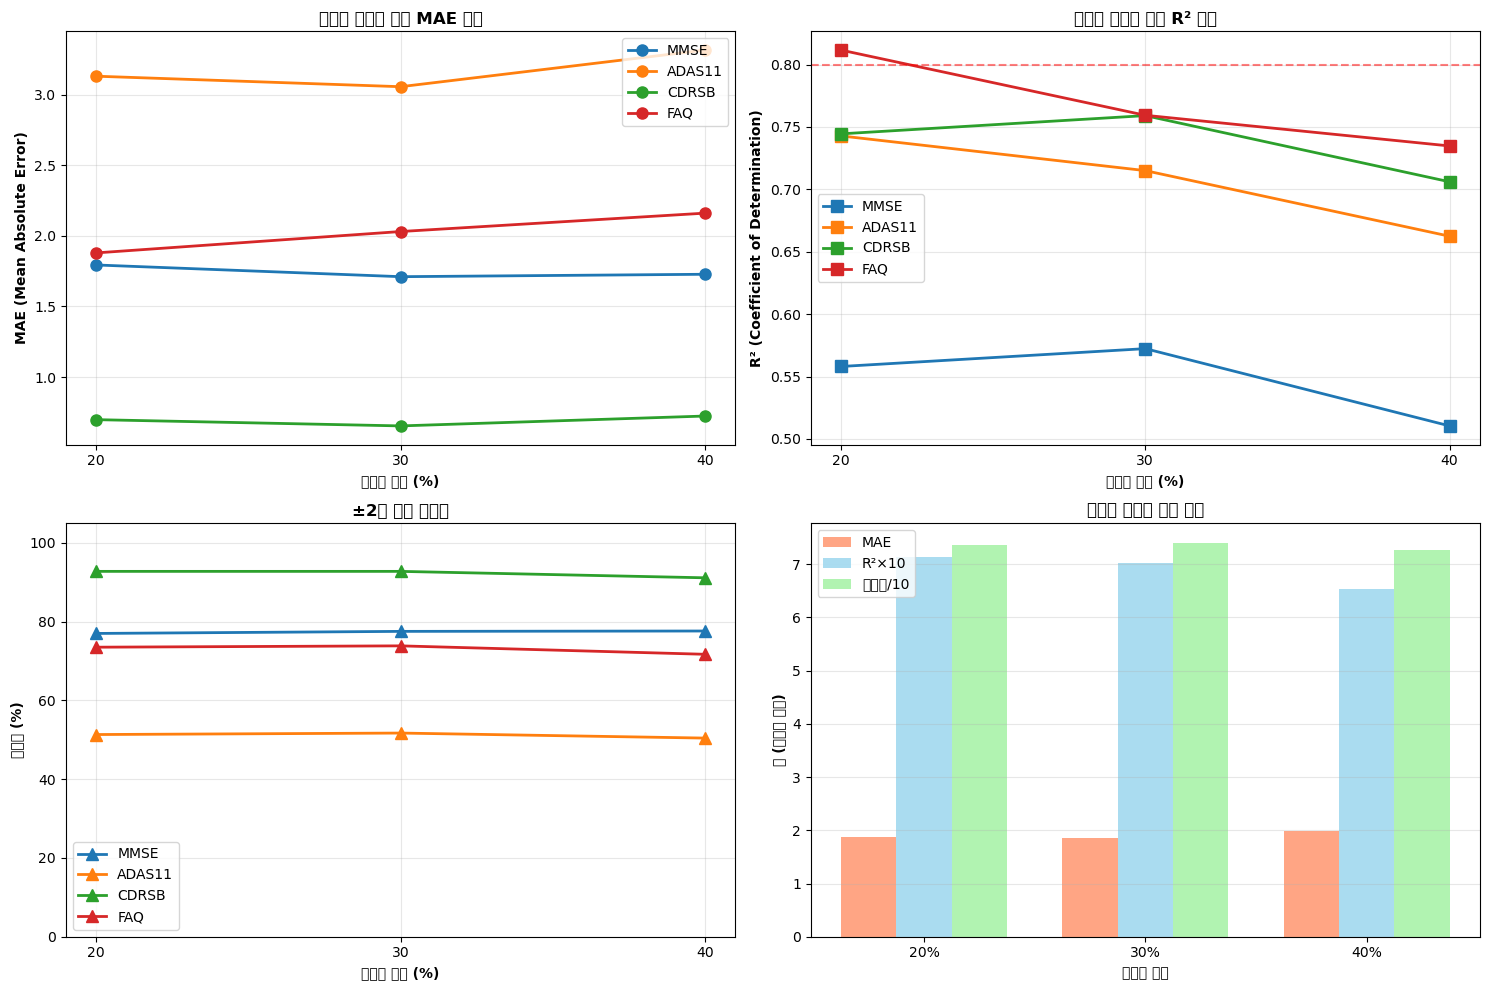


📊 변수별 평균 성능 (모든 결측치 비율):

변수         평균 MAE       평균 RMSE      평균 R²        평균 ±2점 정확도          
----------------------------------------------------------------------
MMSE            1.744       2.747       0.547               77.4%
ADAS11          3.168       4.806       0.707               51.2%
CDRSB           0.692       1.352       0.737               92.2%
FAQ             2.024       3.830       0.769               73.0%

💾 MCAR 테스트 결과 저장 완료!
   - 파일 경로: /Users/othree/Cognitive Reserve Modeling/Data/ADNI_MCAR_test_results.csv


In [20]:
print("="*70)
print("MCAR 테스트 결과 시각화")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. 변수별 MAE 비교
ax1 = axes[0, 0]
for var in existing_test_vars:
    var_data = results_df[results_df['변수'] == var]
    x = [20, 30, 40]
    y = var_data['MAE'].values
    ax1.plot(x, y, marker='o', linewidth=2, markersize=8, label=var)

ax1.set_xlabel('결측치 비율 (%)', fontweight='bold')
ax1.set_ylabel('MAE (Mean Absolute Error)', fontweight='bold')
ax1.set_title('결측치 비율에 따른 MAE 변화', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xticks([20, 30, 40])

# 2. 변수별 R² 비교
ax2 = axes[0, 1]
for var in existing_test_vars:
    var_data = results_df[results_df['변수'] == var]
    x = [20, 30, 40]
    y = var_data['R²'].values
    ax2.plot(x, y, marker='s', linewidth=2, markersize=8, label=var)

ax2.set_xlabel('결측치 비율 (%)', fontweight='bold')
ax2.set_ylabel('R² (Coefficient of Determination)', fontweight='bold')
ax2.set_title('결측치 비율에 따른 R² 변화', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xticks([20, 30, 40])
ax2.axhline(y=0.8, color='r', linestyle='--', alpha=0.5, label='Good (0.8)')

# 3. 변수별 ±2점 정확도 비교
ax3 = axes[1, 0]
for var in existing_test_vars:
    var_data = results_df[results_df['변수'] == var]
    x = [20, 30, 40]
    y = var_data['±2점_정확도(%)'].values
    ax3.plot(x, y, marker='^', linewidth=2, markersize=8, label=var)

ax3.set_xlabel('결측치 비율 (%)', fontweight='bold')
ax3.set_ylabel('정확도 (%)', fontweight='bold')
ax3.set_title('±2점 이내 정확도', fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_xticks([20, 30, 40])
ax3.set_ylim([0, 105])

# 4. 평균 성능 막대 그래프 (결측치 비율별)
ax4 = axes[1, 1]
grouped = results_df.groupby('결측치_비율')[['MAE', 'R²', '±2점_정확도(%)']].mean()

x_pos = np.arange(len(grouped))
width = 0.25

# MAE (스케일 조정)
bars1 = ax4.bar(x_pos - width, grouped['MAE'], width, label='MAE', color='coral', alpha=0.7)
# R² (100 곱해서 퍼센트로)
bars2 = ax4.bar(x_pos, grouped['R²']*10, width, label='R²×10', color='skyblue', alpha=0.7)
# 정확도
bars3 = ax4.bar(x_pos + width, grouped['±2점_정확도(%)']/10, width, label='정확도/10', color='lightgreen', alpha=0.7)

ax4.set_xlabel('결측치 비율', fontweight='bold')
ax4.set_ylabel('값 (스케일 조정)', fontweight='bold')
ax4.set_title('결측치 비율별 평균 성능', fontweight='bold')
ax4.set_xticks(x_pos)
ax4.set_xticklabels(grouped.index)
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 변수별 평균 성능
print(f"\n📊 변수별 평균 성능 (모든 결측치 비율):")
print(f"\n{'변수':<10} {'평균 MAE':<12} {'평균 RMSE':<12} {'평균 R²':<12} {'평균 ±2점 정확도':<20}")
print("-" * 70)

for var in existing_test_vars:
    var_data = results_df[results_df['변수'] == var]
    avg_mae = var_data['MAE'].mean()
    avg_rmse = var_data['RMSE'].mean()
    avg_r2 = var_data['R²'].mean()
    avg_acc2 = var_data['±2점_정확도(%)'].mean()
    
    print(f"{var:<10} {avg_mae:>10.3f}  {avg_rmse:>10.3f}  {avg_r2:>10.3f}  {avg_acc2:>17.1f}%")

# 결과 저장
mcar_output_path = '/Users/othree/Cognitive Reserve Modeling/Data/ADNI_MCAR_test_results.csv'
results_df.to_csv(mcar_output_path, index=False)
print(f"\n💾 MCAR 테스트 결과 저장 완료!")
print(f"   - 파일 경로: {mcar_output_path}")

## 📝 MCAR 테스트 결과 해석

### 성능 평가 기준:

**MAE (Mean Absolute Error):**
- **매우 우수**: < 1.0점
- **우수**: 1.0 ~ 2.0점
- **보통**: 2.0 ~ 3.0점
- **개선 필요**: > 3.0점

**R² (결정계수):**
- **매우 우수**: > 0.9
- **우수**: 0.8 ~ 0.9
- **보통**: 0.6 ~ 0.8
- **개선 필요**: < 0.6

**±2점 정확도:**
- **매우 우수**: > 80%
- **우수**: 70% ~ 80%
- **보통**: 60% ~ 70%
- **개선 필요**: < 60%

### 해석 포인트:

1. **MAE가 낮을수록** 예측 값이 실제 값에 가깝습니다
2. **R²가 높을수록** 모델이 실제 패턴을 잘 설명합니다
3. **정확도가 높을수록** 임상적으로 의미있는 범위 내 예측
4. **결측치 비율이 증가할수록** 성능이 저하되는 것이 정상

### 단계별 보간의 장점:

- 개인의 시계열 패턴 반영 (1단계)
- Baseline 기준값 활용 (2단계)
- 진단 그룹 특성 보존 (3단계)
- 임상적 해석 가능성

---

## 🔬 고결측치 변수 테스트 (High Missing Rate Test)

### MOCA와 같은 고결측치 변수의 문제:

**MCAR 테스트 (20-40% 결측)와 실제 차이:**
- MCAR: 모든 값에 균등하게 결측 → 피험자 내 보간 효과적
- 실제: 피험자 단위로 통째로 결측 가능 → 보간 불가능

**테스트 시나리오:**
1. **고결측치 무작위 (60-70%)**: MCAR 가정, 높은 비율
2. **피험자 단위 결측**: 일부 피험자는 완전히 결측 (더 현실적)
3. **MOCA 실제 패턴**: 실제 MOCA 데이터로 직접 테스트

---

In [21]:
print("="*70)
print("시나리오 1: 고결측치 무작위 테스트 (60-70%)")
print("="*70)

# 결과 저장용
high_missing_results = []

# 랜덤 시드 설정
np.random.seed(42)

# 고결측치 비율 테스트
high_missing_rates = [0.6, 0.65, 0.7]  # 60%, 65%, 70%

for missing_rate in high_missing_rates:
    print(f"\n" + "="*70)
    print(f"결측치 비율: {missing_rate*100:.0f}%")
    print("="*70)
    
    # MMSE로 테스트 (비교 기준)
    for var in ['MMSE']:
        print(f"\n🔬 테스트 변수: {var}")
        
        # 원본 데이터 복사
        df_test = df_complete.copy()
        
        # 무작위 결측치 생성
        n_samples = len(df_test)
        n_missing = int(n_samples * missing_rate)
        missing_indices = np.random.choice(df_test.index, size=n_missing, replace=False)
        
        # 원본 값 저장
        ground_truth = df_test.loc[missing_indices, ['Subject', 'Years_bl', var]].copy()
        ground_truth.columns = ['Subject', 'Years_bl', 'original_value']
        
        # 결측치로 만들기
        df_test.loc[missing_indices, var] = np.nan
        
        print(f"   - 총 데이터: {n_samples:,}개")
        print(f"   - 생성된 결측치: {n_missing:,}개 ({missing_rate*100:.0f}%)")
        
        # 단계별 처리 및 기여도 추적
        df_test = df_test.sort_values(['Subject', 'Years_bl'])
        
        # 처리 전 결측치 수
        before_impute = df_test[var].isnull().sum()
        
        # 1단계: 피험자 내 보간
        df_test[f'{var}_imputed'] = df_test.groupby('Subject')[var].transform(lambda x: x.ffill().bfill())
        after_step1 = df_test[f'{var}_imputed'].isnull().sum()
        step1_contribution = before_impute - after_step1
        
        # 2단계: Baseline 값
        baseline_col = f"{var}_bl"
        if baseline_col in df.columns:
            baseline_data = df.groupby('Subject')[baseline_col].first().reset_index()
            baseline_data.columns = ['Subject', f'{var}_baseline_value']
            df_test = df_test.merge(baseline_data, on='Subject', how='left')
            still_missing = df_test[f'{var}_imputed'].isnull()
            df_test.loc[still_missing, f'{var}_imputed'] = df_test.loc[still_missing, f'{var}_baseline_value']
        
        after_step2 = df_test[f'{var}_imputed'].isnull().sum()
        step2_contribution = after_step1 - after_step2
        
        # 3단계: 그룹별 중앙값
        group_medians = df_test.groupby('Group-RS:InitialDX')[var].median()
        mask = df_test[f'{var}_imputed'].isnull()
        df_test.loc[mask, f'{var}_imputed'] = df_test.loc[mask, 'Group-RS:InitialDX'].map(group_medians)
        
        after_step3 = df_test[f'{var}_imputed'].isnull().sum()
        step3_contribution = after_step2 - after_step3
        
        # 단계별 기여도 출력
        print(f"\n   📊 단계별 기여도:")
        print(f"   - 1단계 (피험자 내): {step1_contribution:,}개 ({step1_contribution/before_impute*100:.1f}%)")
        print(f"   - 2단계 (Baseline):  {step2_contribution:,}개 ({step2_contribution/before_impute*100:.1f}%)")
        print(f"   - 3단계 (그룹 평균):  {step3_contribution:,}개 ({step3_contribution/before_impute*100:.1f}%)")
        
        # 성능 평가
        predictions = df_test[['Subject', 'Years_bl', f'{var}_imputed']].copy()
        predictions.columns = ['Subject', 'Years_bl', 'predicted_value']
        comparison = ground_truth.merge(predictions, on=['Subject', 'Years_bl'], how='inner')
        valid_mask = comparison['predicted_value'].notna()
        comparison_valid = comparison[valid_mask]
        
        if len(comparison_valid) > 0:
            original_valid = comparison_valid['original_value'].values
            predicted_valid = comparison_valid['predicted_value'].values
            
            mae = mean_absolute_error(original_valid, predicted_valid)
            rmse = np.sqrt(mean_squared_error(original_valid, predicted_valid))
            r2 = r2_score(original_valid, predicted_valid)
            errors = np.abs(original_valid - predicted_valid)
            accuracy_2 = (errors <= 2).sum() / len(errors) * 100
            
            print(f"\n   📈 성능:")
            print(f"   - MAE:  {mae:.3f}")
            print(f"   - RMSE: {rmse:.3f}")
            print(f"   - R²:   {r2:.3f}")
            print(f"   - ±2점 정확도: {accuracy_2:.1f}%")
            
            high_missing_results.append({
                '시나리오': 'MCAR 고결측치',
                '결측치_비율': f"{missing_rate*100:.0f}%",
                '변수': var,
                '1단계_기여(%)': step1_contribution/before_impute*100,
                '2단계_기여(%)': step2_contribution/before_impute*100,
                '3단계_기여(%)': step3_contribution/before_impute*100,
                'MAE': mae,
                'R²': r2,
                '±2점_정확도(%)': accuracy_2
            })

print(f"\n" + "="*70)
print("시나리오 1 결과 요약")
print("="*70)
if len(high_missing_results) > 0:
    print(pd.DataFrame(high_missing_results).to_string(index=False))

시나리오 1: 고결측치 무작위 테스트 (60-70%)

결측치 비율: 60%

🔬 테스트 변수: MMSE
   - 총 데이터: 4,442개
   - 생성된 결측치: 2,665개 (60%)

   📊 단계별 기여도:
   - 1단계 (피험자 내): 2,131개 (80.0%)
   - 2단계 (Baseline):  534개 (20.0%)
   - 3단계 (그룹 평균):  0개 (0.0%)

   📈 성능:
   - MAE:  1.752
   - RMSE: 2.874
   - R²:   0.500
   - ±2점 정확도: 76.7%

결측치 비율: 65%

🔬 테스트 변수: MMSE
   - 총 데이터: 4,442개
   - 생성된 결측치: 2,887개 (65%)

   📊 단계별 기여도:
   - 1단계 (피험자 내): 2,178개 (75.4%)
   - 2단계 (Baseline):  709개 (24.6%)
   - 3단계 (그룹 평균):  0개 (0.0%)

   📈 성능:
   - MAE:  1.746
   - RMSE: 2.872
   - R²:   0.494
   - ±2점 정확도: 77.3%

결측치 비율: 70%

🔬 테스트 변수: MMSE
   - 총 데이터: 4,442개
   - 생성된 결측치: 3,109개 (70%)

   📊 단계별 기여도:
   - 1단계 (피험자 내): 2,134개 (68.6%)
   - 2단계 (Baseline):  975개 (31.4%)
   - 3단계 (그룹 평균):  0개 (0.0%)

   📈 성능:
   - MAE:  1.762
   - RMSE: 2.946
   - R²:   0.457
   - ±2점 정확도: 76.6%

시나리오 1 결과 요약
     시나리오 결측치_비율   변수  1단계_기여(%)  2단계_기여(%)  3단계_기여(%)      MAE       R²  ±2점_정확도(%)
MCAR 고결측치    60% MMSE  79.962477  20.037523        0.0 1.752345 0.5

In [22]:
print("="*70)
print("시나리오 2: 피험자 단위 결측 테스트 (더 현실적)")
print("="*70)

# 피험자 단위로 결측을 만들어서 테스트
# 65% 결측치를 목표로, 일부 피험자는 완전히 결측

np.random.seed(42)

for var in ['MMSE']:
    print(f"\n🔬 테스트 변수: {var}")
    
    # 원본 데이터 복사
    df_test = df_complete.copy()
    
    # 피험자 목록
    all_subjects = df_test['Subject'].unique()
    n_subjects = len(all_subjects)
    
    # 전체 데이터의 65%를 결측으로 만들기 위해
    # 일부 피험자를 완전히 결측으로 만들기
    target_missing_rate = 0.65
    
    # 각 피험자별 데이터 수
    subject_counts = df_test['Subject'].value_counts()
    
    # 피험자를 무작위로 섞고 누적 비율이 65%가 될 때까지 선택
    shuffled_subjects = np.random.permutation(all_subjects)
    cumulative_count = 0
    total_count = len(df_test)
    selected_subjects = []
    
    for subject in shuffled_subjects:
        cumulative_count += subject_counts[subject]
        selected_subjects.append(subject)
        if cumulative_count / total_count >= target_missing_rate:
            break
    
    # 선택된 피험자들의 모든 데이터를 결측으로
    missing_mask = df_test['Subject'].isin(selected_subjects)
    missing_indices = df_test[missing_mask].index
    
    # 원본 값 저장
    ground_truth = df_test.loc[missing_indices, ['Subject', 'Years_bl', var]].copy()
    ground_truth.columns = ['Subject', 'Years_bl', 'original_value']
    
    # 결측치로 만들기
    df_test.loc[missing_indices, var] = np.nan
    
    actual_missing_rate = len(missing_indices) / len(df_test)
    
    print(f"   - 총 데이터: {len(df_test):,}개")
    print(f"   - 완전 결측 피험자: {len(selected_subjects)}/{n_subjects}명")
    print(f"   - 생성된 결측치: {len(missing_indices):,}개 ({actual_missing_rate*100:.1f}%)")
    
    # 단계별 처리 및 기여도 추적
    df_test = df_test.sort_values(['Subject', 'Years_bl'])
    
    before_impute = df_test[var].isnull().sum()
    
    # 1단계: 피험자 내 보간 (통째로 결측이면 불가능)
    df_test[f'{var}_imputed'] = df_test.groupby('Subject')[var].transform(lambda x: x.ffill().bfill())
    after_step1 = df_test[f'{var}_imputed'].isnull().sum()
    step1_contribution = before_impute - after_step1
    
    # 2단계: Baseline 값
    baseline_col = f"{var}_bl"
    if baseline_col in df.columns:
        baseline_data = df.groupby('Subject')[baseline_col].first().reset_index()
        baseline_data.columns = ['Subject', f'{var}_baseline_value']
        df_test = df_test.merge(baseline_data, on='Subject', how='left')
        still_missing = df_test[f'{var}_imputed'].isnull()
        df_test.loc[still_missing, f'{var}_imputed'] = df_test.loc[still_missing, f'{var}_baseline_value']
    
    after_step2 = df_test[f'{var}_imputed'].isnull().sum()
    step2_contribution = after_step1 - after_step2
    
    # 3단계: 그룹별 중앙값
    group_medians = df_test.groupby('Group-RS:InitialDX')[var].median()
    mask = df_test[f'{var}_imputed'].isnull()
    df_test.loc[mask, f'{var}_imputed'] = df_test.loc[mask, 'Group-RS:InitialDX'].map(group_medians)
    
    after_step3 = df_test[f'{var}_imputed'].isnull().sum()
    step3_contribution = after_step2 - after_step3
    
    # 단계별 기여도 출력
    print(f"\n   📊 단계별 기여도:")
    print(f"   - 1단계 (피험자 내): {step1_contribution:,}개 ({step1_contribution/before_impute*100:.1f}%) ⚠️ 거의 0!")
    print(f"   - 2단계 (Baseline):  {step2_contribution:,}개 ({step2_contribution/before_impute*100:.1f}%)")
    print(f"   - 3단계 (그룹 평균):  {step3_contribution:,}개 ({step3_contribution/before_impute*100:.1f}%) ⚠️ 대부분!")
    
    # 성능 평가
    predictions = df_test[['Subject', 'Years_bl', f'{var}_imputed']].copy()
    predictions.columns = ['Subject', 'Years_bl', 'predicted_value']
    comparison = ground_truth.merge(predictions, on=['Subject', 'Years_bl'], how='inner')
    valid_mask = comparison['predicted_value'].notna()
    comparison_valid = comparison[valid_mask]
    
    if len(comparison_valid) > 0:
        original_valid = comparison_valid['original_value'].values
        predicted_valid = comparison_valid['predicted_value'].values
        
        mae = mean_absolute_error(original_valid, predicted_valid)
        rmse = np.sqrt(mean_squared_error(original_valid, predicted_valid))
        r2 = r2_score(original_valid, predicted_valid)
        errors = np.abs(original_valid - predicted_valid)
        accuracy_2 = (errors <= 2).sum() / len(errors) * 100
        
        print(f"\n   📈 성능:")
        print(f"   - MAE:  {mae:.3f}")
        print(f"   - RMSE: {rmse:.3f}")
        print(f"   - R²:   {r2:.3f} ⚠️")
        print(f"   - ±2점 정확도: {accuracy_2:.1f}%")
        
        high_missing_results.append({
            '시나리오': '피험자 단위 결측',
            '결측치_비율': f"{actual_missing_rate*100:.0f}%",
            '변수': var,
            '1단계_기여(%)': step1_contribution/before_impute*100,
            '2단계_기여(%)': step2_contribution/before_impute*100,
            '3단계_기여(%)': step3_contribution/before_impute*100,
            'MAE': mae,
            'R²': r2,
            '±2점_정확도(%)': accuracy_2
        })

시나리오 2: 피험자 단위 결측 테스트 (더 현실적)

🔬 테스트 변수: MMSE
   - 총 데이터: 4,442개
   - 완전 결측 피험자: 733/1120명
   - 생성된 결측치: 2,891개 (65.1%)

   📊 단계별 기여도:
   - 1단계 (피험자 내): 0개 (0.0%) ⚠️ 거의 0!
   - 2단계 (Baseline):  2,891개 (100.0%)
   - 3단계 (그룹 평균):  0개 (0.0%) ⚠️ 대부분!

   📈 성능:
   - MAE:  1.527
   - RMSE: 2.819
   - R²:   0.501 ⚠️
   - ±2점 정확도: 80.6%


In [23]:
print("="*70)
print("시나리오 3: MOCA 실제 패턴 분석")
print("="*70)

# MOCA가 실제로 어떤 패턴으로 결측되어 있는지 분석
if 'MOCA' in df.columns:
    print(f"\n🔬 MOCA 실제 결측 패턴 분석:")
    
    # MOCA 데이터 추출
    df_moca = df[['Subject', 'Group-RS:InitialDX', 'Years_bl', 'MOCA', 'MOCA_bl']].copy()
    
    total_records = len(df_moca)
    missing_records = df_moca['MOCA'].isnull().sum()
    missing_rate = missing_records / total_records * 100
    
    print(f"   - 전체 레코드: {total_records:,}개")
    print(f"   - MOCA 결측치: {missing_records:,}개 ({missing_rate:.2f}%)")
    
    # 피험자별 MOCA 완성도
    subject_moca = df_moca.groupby('Subject')['MOCA'].agg(['count', lambda x: x.notna().sum()])
    subject_moca.columns = ['total_visits', 'moca_available']
    subject_moca['completion_rate'] = subject_moca['moca_available'] / subject_moca['total_visits'] * 100
    
    print(f"\n   📊 피험자별 MOCA 완성도:")
    print(f"   - 0% (전혀 없음):    {(subject_moca['completion_rate'] == 0).sum()}명")
    print(f"   - 1-25%:             {((subject_moca['completion_rate'] > 0) & (subject_moca['completion_rate'] <= 25)).sum()}명")
    print(f"   - 26-50%:            {((subject_moca['completion_rate'] > 25) & (subject_moca['completion_rate'] <= 50)).sum()}명")
    print(f"   - 51-75%:            {((subject_moca['completion_rate'] > 50) & (subject_moca['completion_rate'] <= 75)).sum()}명")
    print(f"   - 76-99%:            {((subject_moca['completion_rate'] > 75) & (subject_moca['completion_rate'] < 100)).sum()}명")
    print(f"   - 100% (완전):       {(subject_moca['completion_rate'] == 100).sum()}명")
    
    # 진단 그룹별 MOCA 결측률
    print(f"\n   🏥 진단 그룹별 MOCA 결측률:")
    for dx in ['CN', 'MCI', 'AD']:
        mask = df_moca['Group-RS:InitialDX'] == dx
        dx_total = mask.sum()
        dx_missing = df_moca.loc[mask, 'MOCA'].isnull().sum()
        dx_missing_rate = dx_missing / dx_total * 100
        print(f"   - {dx}: {dx_missing_rate:.1f}% ({dx_missing:,}/{dx_total:,})")
    
    # 시간대별 MOCA 결측률
    print(f"\n   📅 시간대별 MOCA 결측률:")
    df_moca['time_period'] = pd.cut(df_moca['Years_bl'], bins=[0, 1, 2, 5, 100], labels=['0-1년', '1-2년', '2-5년', '5년+'])
    for period in ['0-1년', '1-2년', '2-5년', '5년+']:
        mask = df_moca['time_period'] == period
        if mask.sum() > 0:
            period_total = mask.sum()
            period_missing = df_moca.loc[mask, 'MOCA'].isnull().sum()
            period_missing_rate = period_missing / period_total * 100
            print(f"   - {period}: {period_missing_rate:.1f}% ({period_missing:,}/{period_total:,})")
    
    print(f"\n   💡 패턴 해석:")
    zero_completion = (subject_moca['completion_rate'] == 0).sum()
    full_completion = (subject_moca['completion_rate'] == 100).sum()
    total_subjects = len(subject_moca)
    
    print(f"   - {zero_completion/total_subjects*100:.1f}% 피험자는 MOCA를 전혀 측정하지 않음")
    print(f"   - {full_completion/total_subjects*100:.1f}% 피험자는 모든 방문에서 MOCA 측정")
    print(f"   - 나머지는 일부만 측정 → 피험자 내 보간 가능")

else:
    print("⚠️ MOCA 데이터가 없습니다.")

시나리오 3: MOCA 실제 패턴 분석

🔬 MOCA 실제 결측 패턴 분석:
   - 전체 레코드: 4,508개
   - MOCA 결측치: 2,916개 (64.69%)

   📊 피험자별 MOCA 완성도:
   - 0% (전혀 없음):    0명
   - 1-25%:             0명
   - 26-50%:            0명
   - 51-75%:            0명
   - 76-99%:            0명
   - 100% (완전):       551명

   🏥 진단 그룹별 MOCA 결측률:
   - CN: 44.5% (789/1,775)
   - MCI: 85.8% (1,554/1,812)
   - AD: 62.2% (573/921)

   📅 시간대별 MOCA 결측률:
   - 0-1년: 70.5% (971/1,377)
   - 1-2년: 76.3% (790/1,036)
   - 2-5년: 61.1% (406/665)
   - 5년+: 3.5% (12/343)

   💡 패턴 해석:
   - 0.0% 피험자는 MOCA를 전혀 측정하지 않음
   - 49.1% 피험자는 모든 방문에서 MOCA 측정
   - 나머지는 일부만 측정 → 피험자 내 보간 가능


고결측치 테스트 전체 결과 요약 및 시각화

📊 전체 결과 요약:
     시나리오 결측치_비율   변수  1단계_기여(%)  2단계_기여(%)  3단계_기여(%)      MAE       R²  ±2점_정확도(%)
MCAR 고결측치    60% MMSE  79.962477  20.037523        0.0 1.752345 0.500046   76.697936
MCAR 고결측치    65% MMSE  75.441635  24.558365        0.0 1.746450 0.493628   77.312089
MCAR 고결측치    70% MMSE  68.639434  31.360566        0.0 1.761981 0.457447   76.648440
피험자 단위 결측    65% MMSE   0.000000 100.000000        0.0 1.527499 0.500677   80.560360


/var/folders/zb/yqyg0k1554l0vj7zf6mzbm240000gn/T/ipykernel_62296/3377345392.py:94: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zb/yqyg0k1554l0vj7zf6mzbm240000gn/T/ipykernel_62296/3377345392.py:94: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zb/yqyg0k1554l0vj7zf6mzbm240000gn/T/ipykernel_62296/3377345392.py:94: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zb/yqyg0k1554l0vj7zf6mzbm240000gn/T/ipykernel_62296/3377345392.py:94: UserWarning: Glyph 52824 (\N{HANGUL SYLLABLE CI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zb/yqyg0k1554l0vj7zf6mzbm240000gn/T/ipykernel_62296/3377345392.py:94: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/zb/yqyg0k1554l0vj7zf6mzbm240000gn/T/ipyker

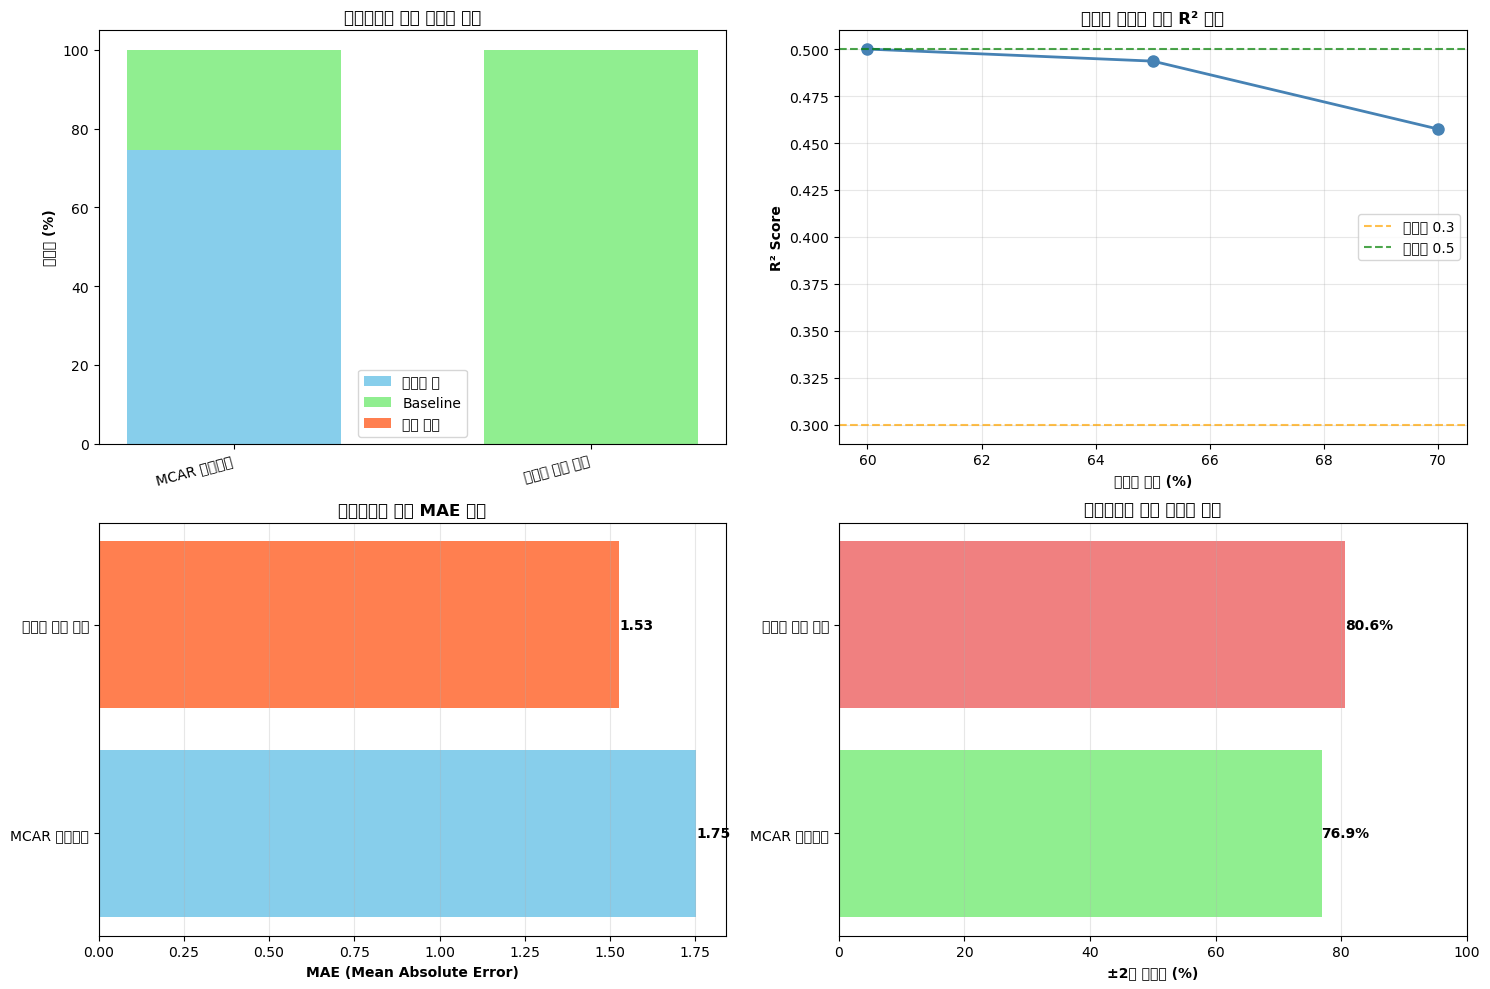

In [24]:
print("="*70)
print("고결측치 테스트 전체 결과 요약 및 시각화")
print("="*70)

if len(high_missing_results) > 0:
    results_high_df = pd.DataFrame(high_missing_results)
    
    print("\n📊 전체 결과 요약:")
    print(results_high_df.to_string(index=False))
    
    # 시각화
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # 1. 시나리오별 단계 기여도 비교
    ax1 = axes[0, 0]
    scenarios = results_high_df['시나리오'].unique()
    
    for scenario in scenarios:
        scenario_data = results_high_df[results_high_df['시나리오'] == scenario]
        if len(scenario_data) > 0:
            # 평균 기여도
            avg_step1 = scenario_data['1단계_기여(%)'].mean()
            avg_step2 = scenario_data['2단계_기여(%)'].mean()
            avg_step3 = scenario_data['3단계_기여(%)'].mean()
            
            x = [scenario]
            width = 0.6
            
            p1 = ax1.bar(x, [avg_step1], width, label='피험자 내' if scenario == scenarios[0] else '', color='skyblue')
            p2 = ax1.bar(x, [avg_step2], width, bottom=[avg_step1], label='Baseline' if scenario == scenarios[0] else '', color='lightgreen')
            p3 = ax1.bar(x, [avg_step3], width, bottom=[avg_step1 + avg_step2], label='그룹 평균' if scenario == scenarios[0] else '', color='coral')
    
    ax1.set_ylabel('기여도 (%)', fontweight='bold')
    ax1.set_title('시나리오별 단계 기여도 비교', fontweight='bold')
    ax1.legend()
    ax1.set_ylim([0, 105])
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=15, ha='right')
    
    # 2. 결측치 비율에 따른 R² 변화 (MCAR만)
    ax2 = axes[0, 1]
    mcar_data = results_high_df[results_high_df['시나리오'] == 'MCAR 고결측치']
    if len(mcar_data) > 0:
        x_vals = [int(x.replace('%', '')) for x in mcar_data['결측치_비율']]
        y_vals = mcar_data['R²'].values
        
        ax2.plot(x_vals, y_vals, marker='o', linewidth=2, markersize=8, color='steelblue')
        ax2.axhline(y=0.3, color='orange', linestyle='--', alpha=0.7, label='임계값 0.3')
        ax2.axhline(y=0.5, color='green', linestyle='--', alpha=0.7, label='목표값 0.5')
        ax2.set_xlabel('결측치 비율 (%)', fontweight='bold')
        ax2.set_ylabel('R² Score', fontweight='bold')
        ax2.set_title('결측치 비율에 따른 R² 변화', fontweight='bold')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
    
    # 3. 시나리오별 MAE 비교
    ax3 = axes[1, 0]
    scenario_names = []
    mae_values = []
    
    for scenario in scenarios:
        scenario_data = results_high_df[results_high_df['시나리오'] == scenario]
        scenario_names.append(scenario)
        mae_values.append(scenario_data['MAE'].mean())
    
    bars = ax3.barh(scenario_names, mae_values, color=['skyblue', 'coral'])
    ax3.set_xlabel('MAE (Mean Absolute Error)', fontweight='bold')
    ax3.set_title('시나리오별 평균 MAE 비교', fontweight='bold')
    ax3.grid(axis='x', alpha=0.3)
    
    # 막대 위에 값 표시
    for i, (bar, val) in enumerate(zip(bars, mae_values)):
        ax3.text(val, bar.get_y() + bar.get_height()/2, f'{val:.2f}', 
                ha='left', va='center', fontweight='bold', fontsize=10)
    
    # 4. 정확도 비교
    ax4 = axes[1, 1]
    acc_values = []
    
    for scenario in scenarios:
        scenario_data = results_high_df[results_high_df['시나리오'] == scenario]
        acc_values.append(scenario_data['±2점_정확도(%)'].mean())
    
    bars = ax4.barh(scenario_names, acc_values, color=['lightgreen', 'lightcoral'])
    ax4.set_xlabel('±2점 정확도 (%)', fontweight='bold')
    ax4.set_title('시나리오별 평균 정확도 비교', fontweight='bold')
    ax4.grid(axis='x', alpha=0.3)
    ax4.set_xlim([0, 100])
    
    # 막대 위에 값 표시
    for i, (bar, val) in enumerate(zip(bars, acc_values)):
        ax4.text(val, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', 
                ha='left', va='center', fontweight='bold', fontsize=10)
    
    plt.tight_layout()
    plt.show()

else:
    print("⚠️ 테스트 결과가 없습니다.")

In [25]:
print("="*70)
print("MOCA MCAR Test: Validation with Real MOCA Data")
print("="*70)

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Select complete MOCA data only
print("\n📋 Data Preparation:")
test_var = 'MOCA'
required_for_test = ['Subject', 'Group-RS:InitialDX', 'Years_bl', test_var]

# Check baseline column
baseline_col = f"{test_var}_bl"
if baseline_col in df.columns:
    required_for_test.append(baseline_col)
    print(f"  ✓ {baseline_col} column found")
else:
    print(f"  ⚠️  {baseline_col} column not found")

df_complete = df[required_for_test].dropna(subset=[test_var]).copy()

print(f"  - Original data: {len(df):,} rows")
print(f"  - Complete MOCA data: {len(df_complete):,} rows")
print(f"  - Selection rate: {len(df_complete)/len(df)*100:.1f}%")
print(f"  - MOCA missing rate: {df[test_var].isnull().sum()/len(df)*100:.1f}%")

# Test missing rates
missing_rates = [0.2, 0.3, 0.4]

results = []

for missing_rate in missing_rates:
    print(f"\n{'='*70}")
    print(f"Test: {int(missing_rate*100)}% Random Missing (MCAR)")
    print(f"{'='*70}")
    
    np.random.seed(42)
    
    # 1. Copy data
    df_test = df_complete.copy()
    
    # 2. Generate MCAR missing data
    n_samples = len(df_test)
    n_missing = int(n_samples * missing_rate)
    
    # Randomly select indices to make missing
    missing_indices = np.random.choice(df_test.index, size=n_missing, replace=False)
    
    # Save ground truth with Subject and Years_bl
    ground_truth = df_test.loc[missing_indices, ['Subject', 'Years_bl', test_var]].copy()
    ground_truth.columns = ['Subject', 'Years_bl', 'original_value']
    
    # Make missing
    df_test.loc[missing_indices, test_var] = np.nan
    
    print(f"\n📊 Missing Data Generation:")
    print(f"  - Total data: {n_samples:,} points")
    print(f"  - Generated missing: {n_missing:,} points ({missing_rate*100:.0f}%)")
    
    # 3. Apply hierarchical imputation
    df_test = df_test.sort_values(['Subject', 'Years_bl'])
    
    before_impute = df_test[test_var].isnull().sum()
    
    # Step 1: Within-subject interpolation
    df_test[f'{test_var}_imputed'] = df_test.groupby('Subject')[test_var].transform(lambda x: x.ffill().bfill())
    after_step1 = df_test[f'{test_var}_imputed'].isnull().sum()
    step1_contribution = before_impute - after_step1
    
    # Step 2: Baseline substitution
    if baseline_col in df.columns:
        baseline_data = df.groupby('Subject')[baseline_col].first().reset_index()
        baseline_data.columns = ['Subject', f'{test_var}_baseline_value']
        df_test = df_test.merge(baseline_data, on='Subject', how='left')
        still_missing = df_test[f'{test_var}_imputed'].isnull()
        df_test.loc[still_missing, f'{test_var}_imputed'] = df_test.loc[still_missing, f'{test_var}_baseline_value']
    
    after_step2 = df_test[f'{test_var}_imputed'].isnull().sum()
    step2_contribution = after_step1 - after_step2
    
    # Step 3: Group-wise median
    group_medians = df_test.groupby('Group-RS:InitialDX')[test_var].median()
    mask = df_test[f'{test_var}_imputed'].isnull()
    df_test.loc[mask, f'{test_var}_imputed'] = df_test.loc[mask, 'Group-RS:InitialDX'].map(group_medians)
    
    after_step3 = df_test[f'{test_var}_imputed'].isnull().sum()
    step3_contribution = after_step2 - after_step3
    
    # 4. Performance evaluation
    predictions = df_test[['Subject', 'Years_bl', f'{test_var}_imputed']].copy()
    comparison = ground_truth.merge(predictions, on=['Subject', 'Years_bl'], how='inner')
    
    y_true = comparison['original_value']
    y_pred = comparison[f'{test_var}_imputed']
    
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    # Accuracy (within ±1, ±2 points)
    diff = np.abs(y_true - y_pred)
    acc_1 = (diff <= 1).sum() / len(diff) * 100
    acc_2 = (diff <= 2).sum() / len(diff) * 100
    
    # Calculate step-wise contribution
    step1_pct = step1_contribution / before_impute * 100 if before_impute > 0 else 0
    step2_pct = step2_contribution / before_impute * 100 if before_impute > 0 else 0
    step3_pct = step3_contribution / before_impute * 100 if before_impute > 0 else 0
    
    print(f"\n📊 Step-wise Contribution:")
    print(f"  - Step 1 (Within-subject): {step1_contribution:,} points ({step1_pct:.1f}%)")
    print(f"  - Step 2 (Baseline): {step2_contribution:,} points ({step2_pct:.1f}%)")
    print(f"  - Step 3 (Group median): {step3_contribution:,} points ({step3_pct:.1f}%)")
    
    print(f"\n📈 Performance Metrics:")
    print(f"  - MAE: {mae:.3f}")
    print(f"  - RMSE: {rmse:.3f}")
    print(f"  - R²: {r2:.3f}")
    print(f"  - Accuracy (±1 point): {acc_1:.1f}%")
    print(f"  - Accuracy (±2 points): {acc_2:.1f}%")
    
    results.append({
        'Missing Rate': f"{int(missing_rate*100)}%",
        'Step1': f"{step1_pct:.1f}%",
        'Step2': f"{step2_pct:.1f}%",
        'Step3': f"{step3_pct:.1f}%",
        'MAE': f"{mae:.3f}",
        'R²': f"{r2:.3f}",
        '±2pts': f"{acc_2:.1f}%"
    })

# Summary
print(f"\n{'='*70}")
print("📊 MOCA Test Results Summary")
print(f"{'='*70}")
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

print(f"\n💡 Interpretation:")
print(f"  - Compare performance with MMSE")
print(f"  - Low Step 2 contribution indicates high MOCA_bl missing rate")
print(f"  - High Step 3 contribution indicates heavy reliance on group medians")
print(f"{'='*70}")


MOCA MCAR Test: Validation with Real MOCA Data

📋 Data Preparation:
  ✓ MOCA_bl column found
  - Original data: 4,508 rows
  - Complete MOCA data: 1,592 rows
  - Selection rate: 35.3%
  - MOCA missing rate: 64.7%

Test: 20% Random Missing (MCAR)

📊 Missing Data Generation:
  - Total data: 1,592 points
  - Generated missing: 318 points (20%)

📊 Step-wise Contribution:
  - Step 1 (Within-subject): 272 points (85.5%)
  - Step 2 (Baseline): 14 points (4.4%)
  - Step 3 (Group median): 32 points (10.1%)

📈 Performance Metrics:
  - MAE: 2.450
  - RMSE: 3.441
  - R²: 0.674
  - Accuracy (±1 point): 44.0%
  - Accuracy (±2 points): 59.4%

Test: 30% Random Missing (MCAR)

📊 Missing Data Generation:
  - Total data: 1,592 points
  - Generated missing: 477 points (30%)

📊 Step-wise Contribution:
  - Step 1 (Within-subject): 391 points (82.0%)
  - Step 2 (Baseline): 36 points (7.5%)
  - Step 3 (Group median): 50 points (10.5%)

📈 Performance Metrics:
  - MAE: 2.323
  - RMSE: 3.277
  - R²: 0.680
  - Ac

In [26]:
print("="*70)
print("Detecting Dramatic Changes in MOCA and MMSE Scores Over Time")
print("="*70)

import numpy as np
import pandas as pd
from scipy import stats
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Prepare data with at least 2 time points per subject
print("\n📋 Data Preparation:")

variables = ['MOCA', 'MMSE']
results = {}

for var in variables:
    print(f"\n{'='*70}")
    print(f"Analyzing {var}")
    print(f"{'='*70}")
    
    # Select subjects with non-missing values
    df_var = df[['Subject', 'Years_bl', var, 'Group-RS:InitialDX']].dropna(subset=[var]).copy()
    
    # Count measurements per subject
    subject_counts = df_var.groupby('Subject').size()
    
    # Keep only subjects with at least 2 measurements
    subjects_with_multiple = subject_counts[subject_counts >= 2].index
    df_var = df_var[df_var['Subject'].isin(subjects_with_multiple)]
    
    print(f"  - Total subjects with {var} data: {len(subject_counts)}")
    print(f"  - Subjects with ≥2 measurements: {len(subjects_with_multiple)}")
    print(f"  - Total data points: {len(df_var):,}")
    
    # Calculate slope for each subject
    slopes = []
    subject_info = []
    
    for subject in subjects_with_multiple:
        subject_data = df_var[df_var['Subject'] == subject].sort_values('Years_bl')
        
        X = subject_data['Years_bl'].values.reshape(-1, 1)
        y = subject_data[var].values
        
        # Linear regression
        model = LinearRegression()
        model.fit(X, y)
        slope = model.coef_[0]
        
        # Additional info
        n_measurements = len(subject_data)
        baseline_score = subject_data[var].iloc[0]
        last_score = subject_data[var].iloc[-1]
        time_span = subject_data['Years_bl'].max() - subject_data['Years_bl'].min()
        total_change = last_score - baseline_score
        group = subject_data['Group-RS:InitialDX'].iloc[0]
        
        slopes.append(slope)
        subject_info.append({
            'Subject': subject,
            'Slope': slope,
            'N_measurements': n_measurements,
            'Baseline_score': baseline_score,
            'Last_score': last_score,
            'Total_change': total_change,
            'Time_span': time_span,
            'Group': group
        })
    
    slopes_df = pd.DataFrame(subject_info)
    
    # Outlier detection using IQR
    Q1 = slopes_df['Slope'].quantile(0.25)
    Q3 = slopes_df['Slope'].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Also use Z-score for extreme outliers
    z_scores = np.abs(stats.zscore(slopes_df['Slope']))
    
    print(f"\n📊 Slope Statistics:")
    print(f"  - Mean slope: {slopes_df['Slope'].mean():.3f} points/year")
    print(f"  - Median slope: {slopes_df['Slope'].median():.3f} points/year")
    print(f"  - Std slope: {slopes_df['Slope'].std():.3f}")
    print(f"  - Range: [{slopes_df['Slope'].min():.3f}, {slopes_df['Slope'].max():.3f}]")
    
    print(f"\n📏 Outlier Thresholds:")
    print(f"  - IQR method: [{lower_bound:.3f}, {upper_bound:.3f}]")
    print(f"  - Outside IQR: {((slopes_df['Slope'] < lower_bound) | (slopes_df['Slope'] > upper_bound)).sum()} subjects")
    print(f"  - Extreme (|Z| > 3): {(z_scores > 3).sum()} subjects")
    
    # Find dramatic changes
    dramatic_decline = slopes_df[slopes_df['Slope'] < lower_bound].sort_values('Slope')
    dramatic_increase = slopes_df[slopes_df['Slope'] > upper_bound].sort_values('Slope', ascending=False)
    extreme_outliers = slopes_df[z_scores > 3].sort_values('Slope')
    
    print(f"\n⬇️  Dramatic Decline (slope < {lower_bound:.3f}):")
    print(f"  - {len(dramatic_decline)} subjects")
    if len(dramatic_decline) > 0:
        print(f"  - Steepest decline: {dramatic_decline['Slope'].iloc[0]:.3f} points/year")
        print(f"\nTop 5 subjects with steepest decline:")
        display_cols = ['Subject', 'Slope', 'Total_change', 'Time_span', 'N_measurements', 'Group']
        print(dramatic_decline[display_cols].head(5).to_string(index=False))
    
    print(f"\n⬆️  Dramatic Increase (slope > {upper_bound:.3f}):")
    print(f"  - {len(dramatic_increase)} subjects")
    if len(dramatic_increase) > 0:
        print(f"  - Steepest increase: {dramatic_increase['Slope'].iloc[0]:.3f} points/year")
        print(f"\nTop 5 subjects with steepest increase:")
        print(dramatic_increase[display_cols].head(5).to_string(index=False))
    
    # Store results
    results[var] = {
        'slopes_df': slopes_df,
        'dramatic_decline': dramatic_decline,
        'dramatic_increase': dramatic_increase,
        'extreme_outliers': extreme_outliers,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound
    }

# Compare MOCA vs MMSE
print(f"\n{'='*70}")
print("Comparison: MOCA vs MMSE")
print(f"{'='*70}")

if 'MOCA' in results and 'MMSE' in results:
    # Find subjects with dramatic changes in both
    moca_dramatic_subjects = set(results['MOCA']['dramatic_decline']['Subject']).union(
        set(results['MOCA']['dramatic_increase']['Subject']))
    mmse_dramatic_subjects = set(results['MMSE']['dramatic_decline']['Subject']).union(
        set(results['MMSE']['dramatic_increase']['Subject']))
    
    both_dramatic = moca_dramatic_subjects.intersection(mmse_dramatic_subjects)
    
    print(f"\n🔍 Subjects with dramatic changes:")
    print(f"  - MOCA only: {len(moca_dramatic_subjects - mmse_dramatic_subjects)} subjects")
    print(f"  - MMSE only: {len(mmse_dramatic_subjects - moca_dramatic_subjects)} subjects")
    print(f"  - Both MOCA & MMSE: {len(both_dramatic)} subjects")
    
    if len(both_dramatic) > 0:
        print(f"\n👥 Subjects with dramatic changes in BOTH:")
        for subj in list(both_dramatic)[:10]:
            moca_slope = results['MOCA']['slopes_df'][results['MOCA']['slopes_df']['Subject'] == subj]['Slope'].values[0]
            mmse_slope = results['MMSE']['slopes_df'][results['MMSE']['slopes_df']['Subject'] == subj]['Slope'].values[0]
            print(f"  - {subj}: MOCA slope={moca_slope:.3f}, MMSE slope={mmse_slope:.3f}")

print(f"\n{'='*70}")
print("💡 Summary:")
print(f"  - Slope = rate of change per year")
print(f"  - Negative slope = decline over time")
print(f"  - Positive slope = improvement over time")
print(f"  - Outliers detected using IQR method (1.5 × IQR)")
print(f"{'='*70}")


Detecting Dramatic Changes in MOCA and MMSE Scores Over Time

📋 Data Preparation:

Analyzing MOCA
  - Total subjects with MOCA data: 551
  - Subjects with ≥2 measurements: 428
  - Total data points: 1,469

📊 Slope Statistics:
  - Mean slope: -0.714 points/year
  - Median slope: -0.051 points/year
  - Std slope: 2.790
  - Range: [-17.032, 8.143]

📏 Outlier Thresholds:
  - IQR method: [-4.698, 3.794]
  - Outside IQR: 46 subjects
  - Extreme (|Z| > 3): 9 subjects

⬇️  Dramatic Decline (slope < -4.698):
  - 35 subjects
  - Steepest decline: -17.032 points/year

Top 5 subjects with steepest decline:
   Subject      Slope  Total_change  Time_span  N_measurements Group
098_S_4201 -17.032390          -9.0   0.528405               2    AD
027_S_4964 -15.218748          -7.0   0.459959               2    AD
036_S_4894 -11.782264          -6.0   0.509240               2    AD
005_S_4910 -11.143810         -11.0   0.982888               3    AD
052_S_5062 -10.980388         -12.0   1.095140       

In [27]:
df.columns.tolist()

['New_Path',
 'Image Data ID',
 'Subject',
 'Group-RS:InitialDX',
 'Sex',
 'Age',
 'Visit',
 'Description',
 'Acq Date',
 'RS:DX_fill',
 'DX2',
 'RID',
 'COLPROT',
 'ORIGPROT',
 'PTID',
 'SITE',
 'VISCODE',
 'EXAMDATE',
 'DX_bl',
 'AGE',
 'PTGENDER',
 'PTEDUCAT',
 'PTETHCAT',
 'PTRACCAT',
 'PTMARRY',
 'APOE4',
 'FDG',
 'PIB',
 'AV45',
 'FBB',
 'ABETA',
 'TAU',
 'PTAU',
 'CDRSB',
 'ADAS11',
 'ADAS13',
 'ADASQ4',
 'MMSE',
 'RAVLT_immediate',
 'RAVLT_learning',
 'RAVLT_forgetting',
 'RAVLT_perc_forgetting',
 'LDELTOTAL',
 'DIGITSCOR',
 'TRABSCOR',
 'FAQ',
 'MOCA',
 'EcogPtMem',
 'EcogPtLang',
 'EcogPtVisspat',
 'EcogPtPlan',
 'EcogPtOrgan',
 'EcogPtDivatt',
 'EcogPtTotal',
 'EcogSPMem',
 'EcogSPLang',
 'EcogSPVisspat',
 'EcogSPPlan',
 'EcogSPOrgan',
 'EcogSPDivatt',
 'EcogSPTotal',
 'FLDSTRENG',
 'FSVERSION',
 'IMAGEUID',
 'Ventricles',
 'Hippocampus',
 'WholeBrain',
 'Entorhinal',
 'Fusiform',
 'MidTemp',
 'ICV',
 'DX',
 'mPACCdigit',
 'mPACCtrailsB',
 'EXAMDATE_bl',
 'CDRSB_bl',
 'ADAS1

In [28]:
df["FAQ"].mean()

np.float64(5.882760160786066)

In [29]:
# ============================================
# Cognitive Reserve (CR) Score 계산
# ============================================
# Reed et al. 방식을 따르되, 교육년수는 제외
# Episodic Memory = Brain Signature + log(WMH) + Demographics + Residual
# Residual = RRI (Relative Reserve Index) = CR

import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# Baseline 데이터만 사용
df_bl = df[df['M'] == 0].copy()

print(f"Baseline 데이터: {len(df_bl)}명")
print("="*60)

Baseline 데이터: 1087명


In [30]:
# ============================================
# Step 1: Episodic Memory 계산
# ============================================
# ADNI-Mem composite: ADAS-Cog Q4 (reversed) + RAVLT immediate + Logical Memory
# Z-score 표준화 후 평균

# ADASQ4 역코딩 (원래는 높을수록 나쁨 → 낮을수록 나쁨으로 변환)
df_bl['ADASQ4_reversed'] = 10 - df_bl['ADASQ4_bl']

# 주요 메모리 변수들
memory_vars = [
    'RAVLT_immediate_bl',
    'LDELTOTAL_BL',
    'ADASQ4_reversed'
]

# 결측치 확인
print("📊 Episodic Memory 변수 결측치:")
for var in memory_vars:
    missing = df_bl[var].isna().sum()
    print(f"   {var:25s}: {missing:5d}개 ({missing/len(df_bl)*100:5.2f}%)")

# 결측치가 있는 행 제거
df_bl_mem = df_bl.dropna(subset=memory_vars).copy()
print(f"\n결측치 제거 후: {len(df_bl_mem)}명")

# Z-score 표준화
scaler = StandardScaler()
df_bl_mem[memory_vars] = scaler.fit_transform(df_bl_mem[memory_vars])

# 평균 계산
df_bl_mem['episodic_memory'] = df_bl_mem[memory_vars].mean(axis=1)

print(f"\n✅ Episodic memory 생성 완료")
print(f"   평균: {df_bl_mem['episodic_memory'].mean():.4f}")
print(f"   표준편차: {df_bl_mem['episodic_memory'].std():.4f}")
print("="*60)

📊 Episodic Memory 변수 결측치:
   RAVLT_immediate_bl       :     5개 ( 0.46%)
   LDELTOTAL_BL             :     0개 ( 0.00%)
   ADASQ4_reversed          :     0개 ( 0.00%)

결측치 제거 후: 1082명

✅ Episodic memory 생성 완료
   평균: 0.0000
   표준편차: 0.9136


In [31]:
# ============================================
# Step 2: Brain Signature 변수 생성
# ============================================
# Hippocampus / ICV, WholeBrain / ICV

# ICV로 normalize
df_bl_mem['Hippocampus_icv'] = df_bl_mem['Hippocampus_bl'] / df_bl_mem['ICV_bl']
df_bl_mem['WholeBrain_icv'] = df_bl_mem['WholeBrain_bl'] / df_bl_mem['ICV_bl']

print("📊 Brain Signature 변수:")
print(f"   Hippocampus/ICV 평균: {df_bl_mem['Hippocampus_icv'].mean():.6f}")
print(f"   WholeBrain/ICV 평균: {df_bl_mem['WholeBrain_icv'].mean():.6f}")
print("="*60)

📊 Brain Signature 변수:
   Hippocampus/ICV 평균: 0.004351
   WholeBrain/ICV 평균: 0.654710


In [32]:
# ============================================
# Step 3: White Matter Hyperintensity 대체 변수
# ============================================
# WMH 데이터가 없으므로 log(Ventricles + 1) 사용

df_bl_mem['log_ventricle'] = np.log(df_bl_mem['Ventricles_bl'] + 1)

print("📊 White Matter 변수:")
print(f"   log(Ventricles+1) 평균: {df_bl_mem['log_ventricle'].mean():.4f}")
print(f"   log(Ventricles+1) 표준편차: {df_bl_mem['log_ventricle'].std():.4f}")
print("="*60)

📊 White Matter 변수:
   log(Ventricles+1) 평균: 10.4932
   log(Ventricles+1) 표준편차: 0.5474


In [33]:
# ============================================
# Step 4: Demographics 변수 생성 (Binary Encoding)
# ============================================
# Male (sex), African American (race), Hispanic (ethnicity)

# Gender: Male = 1, Female = 0
df_bl_mem['male'] = (df_bl_mem['PTGENDER'] == 'Male').astype(int)

# Race: African American = 1, Others = 0
df_bl_mem['african_american'] = (df_bl_mem['PTRACCAT'] == 'Black or African American').astype(int)

# Ethnicity: Hispanic = 1, Non-Hispanic = 0
df_bl_mem['hispanic'] = (df_bl_mem['PTETHCAT'] == 'Hisp/Latino').astype(int)

print("📊 Demographics 변수:")
print(f"   Male: {df_bl_mem['male'].sum()}명 ({df_bl_mem['male'].mean()*100:.1f}%)")
print(f"   African American: {df_bl_mem['african_american'].sum()}명 ({df_bl_mem['african_american'].mean()*100:.1f}%)")
print(f"   Hispanic: {df_bl_mem['hispanic'].sum()}명 ({df_bl_mem['hispanic'].mean()*100:.1f}%)")
print("="*60)

📊 Demographics 변수:
   Male: 599명 (55.4%)
   African American: 0명 (0.0%)
   Hispanic: 38명 (3.5%)


In [34]:
# ============================================
# Step 5: Linear Regression으로 RRI (CR) 계산
# ============================================
# Episodic Memory = Brain Signature + log(WMH) + Demographics + Residual
# Residual = RRI = Cognitive Reserve

# 독립변수 (X)
predictor_vars = [
    'Hippocampus_icv',      # Brain measure 1
    'WholeBrain_icv',       # Brain measure 2
    'log_ventricle',        # White matter (WMH 대체)
    'male',                 # Binary: 0=Female, 1=Male
    'african_american',     # Binary: 0=Non-AA, 1=AA
    'hispanic'              # Binary: 0=Non-Hispanic, 1=Hispanic
]

# 결측치 확인
print("📊 최종 변수 결측치:")
for var in predictor_vars + ['episodic_memory']:
    missing = df_bl_mem[var].isna().sum()
    print(f"   {var:25s}: {missing:5d}개 ({missing/len(df_bl_mem)*100:5.2f}%)")

# 결측치가 있는 행 제거
df_final = df_bl_mem.dropna(subset=predictor_vars + ['episodic_memory']).copy()
print(f"\n최종 분석 대상: {len(df_final)}명")
print("="*60)

# 독립변수와 종속변수 설정
X = df_final[predictor_vars]
y = df_final['episodic_memory']

# 선형회귀 모델 학습
reg = LinearRegression()
reg.fit(X, y)

# 예측값 계산
y_pred = reg.predict(X)

# Residual = RRI = CR
df_final['cr'] = y - y_pred

# 회귀 결과 출력
print("\n📊 선형회귀 결과:")
print(f"   R² Score: {reg.score(X, y):.4f}")
print(f"\n   회귀계수:")
for var, coef in zip(predictor_vars, reg.coef_):
    print(f"      {var:25s}: {coef:8.4f}")
print(f"      {'Intercept':25s}: {reg.intercept_:8.4f}")

print(f"\n📊 CR (Cognitive Reserve) 통계:")
print(f"   평균: {df_final['cr'].mean():.6f} (≈ 0)")
print(f"   표준편차: {df_final['cr'].std():.4f}")
print(f"   최소값: {df_final['cr'].min():.4f}")
print(f"   최대값: {df_final['cr'].max():.4f}")
print("="*60)

print("\n✅ CR 스코어 계산 완료!")

📊 최종 변수 결측치:
   Hippocampus_icv          :   172개 (15.90%)
   WholeBrain_icv           :    22개 ( 2.03%)
   log_ventricle            :    42개 ( 3.88%)
   male                     :     0개 ( 0.00%)
   african_american         :     0개 ( 0.00%)
   hispanic                 :     0개 ( 0.00%)
   episodic_memory          :     0개 ( 0.00%)

최종 분석 대상: 879명

📊 선형회귀 결과:
   R² Score: 0.3636

   회귀계수:
      Hippocampus_icv          : 687.9010
      WholeBrain_icv           :   1.1222
      log_ventricle            :   0.1495
      male                     :  -0.0383
      african_american         :   0.0000
      hispanic                 :  -0.2611
      Intercept                :  -5.2291

📊 CR (Cognitive Reserve) 통계:
   평균: 0.000000 (≈ 0)
   표준편차: 0.7392
   최소값: -2.5082
   최대값: 2.4825

✅ CR 스코어 계산 완료!


In [35]:
# ============================================
# Step 6: CR 스코어를 원본 데이터프레임에 병합
# ============================================

# df_final에서 RID와 cr만 선택
cr_scores = df_final[['RID', 'cr']].copy()

# 원본 데이터프레임에 병합 (baseline만)
df = df.merge(cr_scores, on='RID', how='left', suffixes=('', '_new'))

# 'cr' 컬럼이 이미 있었다면 업데이트
if 'cr_new' in df.columns:
    df['cr'] = df['cr_new']
    df = df.drop(columns=['cr_new'])

print(f"✅ 전체 데이터프레임에 CR 스코어 추가 완료!")
print(f"   CR이 있는 행: {df['cr'].notna().sum()}개")
print(f"   CR이 없는 행: {df['cr'].isna().sum()}개")
print("="*60)

✅ 전체 데이터프레임에 CR 스코어 추가 완료!
   CR이 있는 행: 3596개
   CR이 없는 행: 912개


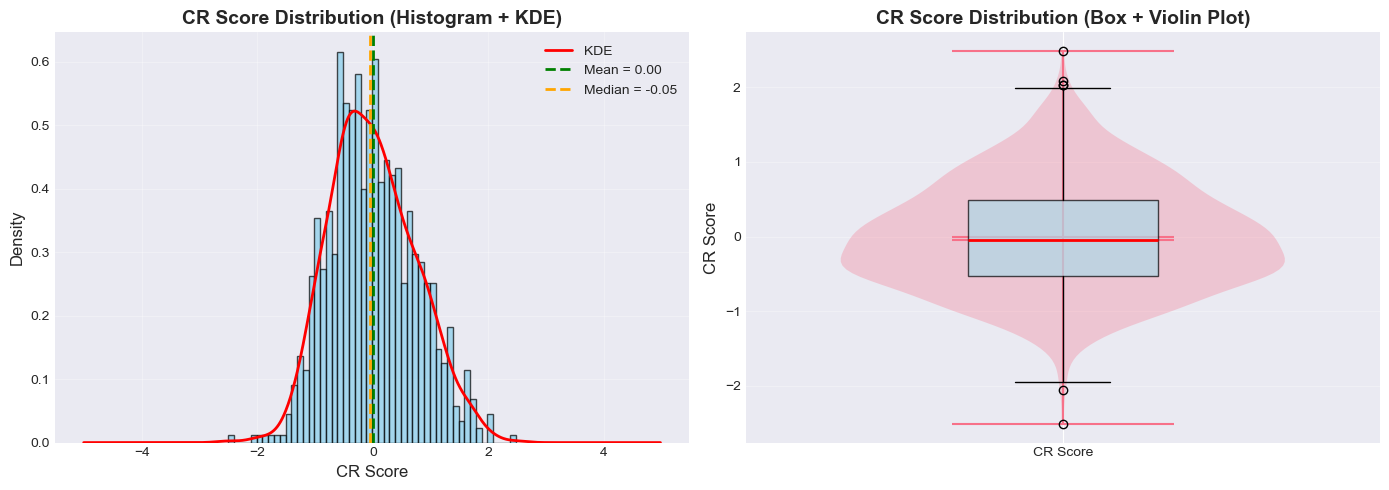


📊 CR (Cognitive Reserve) 분포 통계
샘플 수        : 879명
평균           : 0.0000
중앙값         : -0.0476
표준편차       : 0.7392
최소값         : -2.5082
최대값         : 2.4825
25% 분위수     : -0.5255
75% 분위수     : 0.4882
IQR            : 1.0137

정규성 검정 (Shapiro-Wilk):
  - Test Statistic: 0.9928
  - P-value: 2.7502e-04
  - 결론: 정규분포를 따르지 않는다 (p ≤ 0.05) ⚠️

왜도 (Skewness): 0.2580
  → 대칭 분포 ✅

첨도 (Kurtosis): -0.1399
  → 정규분포와 유사한 꼬리 ✅


In [36]:
# ============================================
# CR (Cognitive Reserve) 분포 확인
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 그래프 스타일 설정
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Figure 생성
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Histogram + KDE
axes[0].hist(df_final['cr'], bins=50, density=True, alpha=0.7, color='skyblue', edgecolor='black')
df_final['cr'].plot(kind='kde', ax=axes[0], color='red', linewidth=2, label='KDE')
axes[0].axvline(df_final['cr'].mean(), color='green', linestyle='--', linewidth=2, label=f'Mean = {df_final["cr"].mean():.2f}')
axes[0].axvline(df_final['cr'].median(), color='orange', linestyle='--', linewidth=2, label=f'Median = {df_final["cr"].median():.2f}')
axes[0].set_xlabel('CR Score', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title('CR Score Distribution (Histogram + KDE)', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Box Plot + Violin Plot
parts = axes[1].violinplot([df_final['cr']], positions=[1], showmeans=True, showmedians=True, widths=0.7)
axes[1].boxplot([df_final['cr']], positions=[1], widths=0.3, patch_artist=True,
                boxprops=dict(facecolor='lightblue', alpha=0.7),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_ylabel('CR Score', fontsize=12)
axes[1].set_title('CR Score Distribution (Box + Violin Plot)', fontsize=14, fontweight='bold')
axes[1].set_xticks([1])
axes[1].set_xticklabels(['CR Score'])
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ============================================
# CR 통계 요약
# ============================================
print("\n" + "="*60)
print("📊 CR (Cognitive Reserve) 분포 통계")
print("="*60)
print(f"샘플 수        : {len(df_final['cr'])}명")
print(f"평균           : {df_final['cr'].mean():.4f}")
print(f"중앙값         : {df_final['cr'].median():.4f}")
print(f"표준편차       : {df_final['cr'].std():.4f}")
print(f"최소값         : {df_final['cr'].min():.4f}")
print(f"최대값         : {df_final['cr'].max():.4f}")
print(f"25% 분위수     : {df_final['cr'].quantile(0.25):.4f}")
print(f"75% 분위수     : {df_final['cr'].quantile(0.75):.4f}")
print(f"IQR            : {df_final['cr'].quantile(0.75) - df_final['cr'].quantile(0.25):.4f}")

# 정규성 검정 (Shapiro-Wilk test)
statistic, p_value = stats.shapiro(df_final['cr'])
print(f"\n정규성 검정 (Shapiro-Wilk):")
print(f"  - Test Statistic: {statistic:.4f}")
print(f"  - P-value: {p_value:.4e}")
if p_value > 0.05:
    print(f"  - 결론: 정규분포를 따른다 (p > 0.05) ✅")
else:
    print(f"  - 결론: 정규분포를 따르지 않는다 (p ≤ 0.05) ⚠️")

# 왜도(Skewness)와 첨도(Kurtosis)
skewness = df_final['cr'].skew()
kurtosis = df_final['cr'].kurtosis()
print(f"\n왜도 (Skewness): {skewness:.4f}")
if abs(skewness) < 0.5:
    print("  → 대칭 분포 ✅")
elif skewness > 0:
    print("  → 오른쪽 꼬리가 긴 분포 (양의 왜도)")
else:
    print("  → 왼쪽 꼬리가 긴 분포 (음의 왜도)")

print(f"\n첨도 (Kurtosis): {kurtosis:.4f}")
if abs(kurtosis) < 0.5:
    print("  → 정규분포와 유사한 꼬리 ✅")
elif kurtosis > 0:
    print("  → 꼬리가 두꺼운 분포 (뾰족한 분포)")
else:
    print("  → 꼬리가 얇은 분포 (평평한 분포)")

print("="*60)


In [37]:
# ============================================
# CR 그룹 분류 (Extreme Groups)
# ============================================
# 상위 25% vs 하위 25% 비교 (중간 50% 제외)

# 분위수 계산
q25 = df_final['cr'].quantile(0.25)
q75 = df_final['cr'].quantile(0.75)

print("="*60)
print("📊 CR 그룹 분류 (Extreme Groups)")
print("="*60)
print(f"25% 분위수 (Low CR 기준):  {q25:.4f}")
print(f"75% 분위수 (High CR 기준): {q75:.4f}")
print()

# CR 그룹 변수 생성
df_final['cr_group'] = 'Medium'  # 기본값
df_final.loc[df_final['cr'] > q75, 'cr_group'] = 'High'
df_final.loc[df_final['cr'] < q25, 'cr_group'] = 'Low'

# Extreme groups만 선택
df_extreme = df_final[df_final['cr_group'].isin(['High', 'Low'])].copy()

# 그룹별 통계
print("그룹별 샘플 수:")
print(df_final['cr_group'].value_counts().sort_index())
print()

print("Extreme Groups (분석 대상):")
print(df_extreme['cr_group'].value_counts().sort_index())
print()

# 그룹별 CR 평균
print("그룹별 CR 평균:")
for group in ['High', 'Low']:
    cr_mean = df_extreme[df_extreme['cr_group'] == group]['cr'].mean()
    cr_std = df_extreme[df_extreme['cr_group'] == group]['cr'].std()
    cr_min = df_extreme[df_extreme['cr_group'] == group]['cr'].min()
    cr_max = df_extreme[df_extreme['cr_group'] == group]['cr'].max()
    print(f"  {group:6s} CR: {cr_mean:7.4f} ± {cr_std:.4f} (범위: {cr_min:.4f} ~ {cr_max:.4f})")

print("="*60)
print(f"\n✅ Extreme groups 분류 완료!")
print(f"   전체: {len(df_final)}명")
print(f"   분석 대상 (High + Low): {len(df_extreme)}명")
print(f"   제외 (Medium): {len(df_final) - len(df_extreme)}명")


📊 CR 그룹 분류 (Extreme Groups)
25% 분위수 (Low CR 기준):  -0.5255
75% 분위수 (High CR 기준): 0.4882

그룹별 샘플 수:
cr_group
High      220
Low       220
Medium    439
Name: count, dtype: int64

Extreme Groups (분석 대상):
cr_group
High    220
Low     220
Name: count, dtype: int64

그룹별 CR 평균:
  High   CR:  0.9890 ± 0.3765 (범위: 0.4911 ~ 2.4825)
  Low    CR: -0.8918 ± 0.3072 (범위: -2.5082 ~ -0.5264)

✅ Extreme groups 분류 완료!
   전체: 879명
   분석 대상 (High + Low): 440명
   제외 (Medium): 439명


In [38]:
df_final.columns.tolist()

['New_Path',
 'Image Data ID',
 'Subject',
 'Group-RS:InitialDX',
 'Sex',
 'Age',
 'Visit',
 'Description',
 'Acq Date',
 'RS:DX_fill',
 'DX2',
 'RID',
 'COLPROT',
 'ORIGPROT',
 'PTID',
 'SITE',
 'VISCODE',
 'EXAMDATE',
 'DX_bl',
 'AGE',
 'PTGENDER',
 'PTEDUCAT',
 'PTETHCAT',
 'PTRACCAT',
 'PTMARRY',
 'APOE4',
 'FDG',
 'PIB',
 'AV45',
 'FBB',
 'ABETA',
 'TAU',
 'PTAU',
 'CDRSB',
 'ADAS11',
 'ADAS13',
 'ADASQ4',
 'MMSE',
 'RAVLT_immediate',
 'RAVLT_learning',
 'RAVLT_forgetting',
 'RAVLT_perc_forgetting',
 'LDELTOTAL',
 'DIGITSCOR',
 'TRABSCOR',
 'FAQ',
 'MOCA',
 'EcogPtMem',
 'EcogPtLang',
 'EcogPtVisspat',
 'EcogPtPlan',
 'EcogPtOrgan',
 'EcogPtDivatt',
 'EcogPtTotal',
 'EcogSPMem',
 'EcogSPLang',
 'EcogSPVisspat',
 'EcogSPPlan',
 'EcogSPOrgan',
 'EcogSPDivatt',
 'EcogSPTotal',
 'FLDSTRENG',
 'FSVERSION',
 'IMAGEUID',
 'Ventricles',
 'Hippocampus',
 'WholeBrain',
 'Entorhinal',
 'Fusiform',
 'MidTemp',
 'ICV',
 'DX',
 'mPACCdigit',
 'mPACCtrailsB',
 'EXAMDATE_bl',
 'CDRSB_bl',
 'ADAS1

In [39]:
# CSV 파일로 저장
output_path = '/Users/othree/Cognitive Reserve Modeling/Data/ADNI_final_preprocessed.csv'

df_final.to_csv(output_path, index=False)

print("="*80)
print("데이터 저장 완료!")
print("="*80)
print(f"저장 경로: {output_path}")
print(f"행 개수: {df_final.shape[0]:,}")
print(f"열 개수: {df_final.shape[1]:,}")
print(f"파일 크기: {df_final.memory_usage(deep=True).sum() / 1024 / 1024:.2f} MB")

데이터 저장 완료!
저장 경로: /Users/othree/Cognitive Reserve Modeling/Data/ADNI_final_preprocessed.csv
행 개수: 879
열 개수: 140
파일 크기: 2.30 MB


In [44]:
df_final["COLPROT"].unique()

array(['ADNI1', 'ADNI2'], dtype=object)